#Import Libraries

In [ ]:
import pandas as pd
import gzip
import json

first import the necessary Python libraries:

- pandas → For handling and manipulating structured data (DataFrames).
- gzip → Since our dataset is stored in a compressed .json.gz format, we use gzip to read it.
- json → To parse JSON-formatted data into a structured format.
These libraries help in efficiently loading and processing large-scale datasets

#load the dataset

In [ ]:
#load the book dataset
# Load the books dataset
def load_books_data(file_path):
    with gzip.open(file_path, 'r') as f:
        data = [json.loads(line) for line in f]
    return pd.DataFrame(data)

it define a function load_books_data(file_path) to load and convert the JSON-formatted data into a Pandas DataFrame.

- gzip.open(file_path, 'r') → Opens the compressed .json.gz file for reading.
- json.loads(line) → Reads each line as a separate JSON object.
- pd.DataFrame(data) → Converts the parsed JSON into a structured DataFrame for analysis.

This function ensures an efficient way to load the dataset while keeping the code reusable.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load the books data
young_books_df1 = load_books_data('/content/drive/MyDrive/goodreads_books_young_adult.json.gz')

In [ ]:
young_books_df1.head()

,isbn,text_reviews_count,series,country_code,language_code,popular_shelves,asin,is_ebook,average_rating,kindle_asin,...,publication_month,edition_information,publication_year,url,image_url,book_id,ratings_count,work_id,title,title_without_series
0,,1,[147734],US,,"[{'count': '1057', 'name': 'to-read'}, {'count...",B0056A00P4,true,4.04,B0056A00P4,...,,,,https://www.goodreads.com/book/show/12182387-t...,https://s.gr-assets.com/assets/nophoto/book/11...,12182387,4,285263,"The Passion (Dark Visions, #3)","The Passion (Dark Visions, #3)"
1,,2,[425995],US,,"[{'count': '1010', 'name': 'to-read'}, {'count...",B006KLYIAG,true,3.80,B006KLYIAG,...,,,,https://www.goodreads.com/book/show/20135365-h...,https://s.gr-assets.com/assets/nophoto/book/11...,20135365,5,18450480,Hope's Daughter,Hope's Daughter
2,0698143760,17,[493993],US,,"[{'count': '1799', 'name': 'fantasy'}, {'count...",,true,3.80,,...,3,,2014,https://www.goodreads.com/book/show/21401181-h...,https://images.gr-assets.com/books/1394747643m...,21401181,33,24802827,"Half Bad (Half Life, #1)","Half Bad (Half Life, #1)"
3,,9,[176160],US,eng,"[{'count': '7173', 'name': 'to-read'}, {'count...",B0042JSOQC,true,4.35,B004IYJDXY,...,,,,https://www.goodreads.com/book/show/10099492-t...,https://s.gr-assets.com/assets/nophoto/book/11...,10099492,152,10800440,Twelfth Grade Kills (The Chronicles of Vladimi...,Twelfth Grade Kills (The Chronicles of Vladimi...
4,0990662616,428,[],US,eng,"[{'count': '9481', 'name': 'to-read'}, {'count...",,false,3.71,B00MW0MTGE,...,10,Special Edition,2014,https://www.goodreads.com/book/show/22642971-t...,https://images.gr-assets.com/books/1406979059m...,22642971,1525,42144295,The Body Electric,The Body Electric


In [ ]:
young_books_df1.shape

(93398, 29)

## Dataset Overview  

The dataset consists of metadata from Young Adult books, primarily used for building book recommendation systems. Each row represents a book and provides rich metadata that helps in understanding user preferences and content-based recommendations.

📊 Dataset Summary:
- Total Records: 93,398 books
- Features (Columns): 29 attributes
- Key Columns:
book_id, title, average_rating, text_reviews_count, language_code, popular_shelves.

Key Observations:
1. Missing Data Analysis
Some fields, such as isbn and language_code, contain missing values.
language_code missing values might require imputation or filtering to ensure language consistency.
Missing isbn values might not affect recommendations but could impact book identification.
2. Book Popularity & User Engagement
average_rating and text_reviews_count provide insights into book quality and popularity.
Books with high ratings are likely to be widely liked, while books with high reviews indicate strong user engagement.
3. Book Format & Digital Presence
The is_ebook column differentiates between digital (eBooks) and physical books.
This could be a useful feature for recommending books based on user format preferences.
4. Popularity Tags & Genre Information
The popular_shelves column contains user-generated genre tags (e.g., "to-read," "fantasy," "mystery").
These tags can be leveraged for content-based filtering, grouping books with similar themes.


# check general info

In [ ]:
young_books_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93398 entries, 0 to 93397
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   isbn                  93398 non-null  object
 1   text_reviews_count    93398 non-null  object
 2   series                93398 non-null  object
 3   country_code          93398 non-null  object
 4   language_code         93398 non-null  object
 5   popular_shelves       93398 non-null  object
 6   asin                  93398 non-null  object
 7   is_ebook              93398 non-null  object
 8   average_rating        93398 non-null  object
 9   kindle_asin           93398 non-null  object
 10  similar_books         93398 non-null  object
 11  description           93398 non-null  object
 12  format                93398 non-null  object
 13  link                  93398 non-null  object
 14  authors               93398 non-null  object
 15  publisher             93398 non-null

After loading the dataset, we analyzed its structure using df.info(), which provides insights into data types, missing values, and memory usage.

###Key Observations
1. Dataset Overview

Total Rows: 93,398

Total Columns: 29

Memory Usage: ~18.5 MB

All Columns are of Object Type, meaning even numerical fields are stored as text.

2. Data Type Issues
- Fields like text_reviews_count, average_rating, num_pages, ratings_count, and publication_year should be numeric but are stored as objects.
- Storing numbers as objects increases memory usage and slows down computations.
Some columns contain missing values (e.g., isbn, description, publisher).

3. Missing Values

- Columns with Nulls: isbn, kindle_asin, description, num_pages, publication_year, isbn13, format, etc.
- Columns with 100% Data: text_reviews_count, country_code, popular_shelves, book_id, title, authors.

#Data type conversion

In [ ]:
young_books_df1['text_reviews_count'] = pd.to_numeric(young_books_df1['text_reviews_count'], errors='coerce')
young_books_df1['ratings_count'] = pd.to_numeric(young_books_df1['ratings_count'], errors='coerce')
young_books_df1['num_pages'] = pd.to_numeric(young_books_df1['num_pages'], errors='coerce')
young_books_df1['publication_year'] = pd.to_numeric(young_books_df1['publication_year'], errors='coerce')
young_books_df1['publication_month'] = pd.to_numeric(young_books_df1['publication_month'], errors='coerce')
young_books_df1['average_rating'] = pd.to_numeric(young_books_df1['average_rating'], errors='coerce')
young_books_df1['series'] = pd.to_numeric(young_books_df1['series'], errors='coerce')
# Verify Changes
young_books_df1.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93398 entries, 0 to 93397
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   isbn                  93398 non-null  object 
 1   text_reviews_count    93398 non-null  int64  
 2   series                0 non-null      float64
 3   country_code          93398 non-null  object 
 4   language_code         93398 non-null  object 
 5   popular_shelves       93398 non-null  object 
 6   asin                  93398 non-null  object 
 7   is_ebook              93398 non-null  object 
 8   average_rating        93398 non-null  float64
 9   kindle_asin           93398 non-null  object 
 10  similar_books         93398 non-null  object 
 11  description           93398 non-null  object 
 12  format                93398 non-null  object 
 13  link                  93398 non-null  object 
 14  authors               93398 non-null  object 
 15  publisher          

#check for missing values

In [ ]:
# Check missing values after data type conversion
missing_values = young_books_df1.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Show only columns with missing values

# Convert to percentage
missing_percentage = (missing_values / len(young_books_df1)) * 100

# Display results
print("Missing Values After Data Type Conversion:\n")
print(pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage.round(2)}))


Missing Values After Data Type Conversion:

                   Missing Values  Percentage
series                      93398      100.00
num_pages                   21703       23.24
publication_month           22083       23.64
publication_year            15503       16.60


Observations:
- High Missing Values in series, isbn and kindle_asin

    - series is 100% missing values. since it is no use in recommendation system it will be removed
    - More than 40% of isbn values are missing, meaning book identification through ISBN is unreliable.
    - 51.55% missing values in kindle_asin indicate it is not consistently recorded across books, making it a weak feature for recommendation models.
    - Action: Likely removal if not critical for book matching.

- Moderate Missing Values in num_pages and publication details

    - num_pages (23.24%) is useful for categorizing books based on length.
    - Publication information (year, month) has moderate missing values but is essential for trend analysis.
    - Action: Consider imputation using median values for numerical columns.

- Low Missing Values in description

    - Only 4.59% of books lack a description, making it useful for NLP models.
    - Action: Drop rows with missing description if needed for content-based filtering.


#Handling Missing Values

In [ ]:
# Drop columns with excessive missing values
young_books_df1.drop(columns=['series','isbn', 'kindle_asin'], inplace=True)

# Fill missing values with median (using .loc[] to avoid chained assignment warning)
young_books_df1.loc[:, 'num_pages'] = young_books_df1['num_pages'].fillna(young_books_df1['num_pages'].median())
young_books_df1.loc[:, 'publication_year'] = young_books_df1['publication_year'].fillna(young_books_df1['publication_year'].median())

# Drop rows where 'description' is missing
young_books_df1 = young_books_df1.dropna(subset=['description']).reset_index(drop=True)

# Check if missing values are resolved
missing_values_after_cleaning = young_books_df1.isnull().sum()
print("Remaining Missing Values After Cleaning:\n", missing_values_after_cleaning[missing_values_after_cleaning > 0])


Remaining Missing Values After Cleaning:
 publication_month    22083
dtype: int64


In [ ]:
# Drop publication_month as it's not crucial for analysis
young_books_df1.drop(columns=['publication_month'], inplace=True)

# Confirm the dataset has no more missing values
print("Final Missing Values After Cleaning:\n", young_books_df1.isnull().sum()[young_books_df1.isnull().sum() > 0])


Final Missing Values After Cleaning:
 Series([], dtype: int64)


In [ ]:
young_books_df1.shape

(93398, 25)

#Normalizing and filter language code

In [ ]:
# Normalize the language codes
young_books_df1['language_code'] = young_books_df1['language_code'].astype(str).str.lower().str.strip()

In [ ]:
# Replace undefined values in language_code
young_books_df1['language_code'] = young_books_df1['language_code'].replace(['', '--', 'nan', 'none'], 'unknown')

In [ ]:
# Define English language codes
english_languages = ['eng', 'en', 'en-us', 'en-gb', 'en-ca']

In [ ]:
# Filter the DataFrame to include only English books
df_english_books = young_books_df1[young_books_df1['language_code'].isin(english_languages)].reset_index(drop=True)

In [ ]:
# Verify the filtering
print("Shape after filtering English books:", df_english_books.shape)
print("Unique Language Codes after filtering:", df_english_books['language_code'].unique())

Shape after filtering English books: (44286, 25)
Unique Language Codes after filtering: ['eng' 'en-us' 'en-ca' 'en-gb' 'en']


In [ ]:
df_english_books.head(5)

,text_reviews_count,country_code,language_code,popular_shelves,asin,is_ebook,average_rating,similar_books,description,format,...,isbn13,edition_information,publication_year,url,image_url,book_id,ratings_count,work_id,title,title_without_series
0,9,US,eng,"[{'count': '7173', 'name': 'to-read'}, {'count...",B0042JSOQC,true,4.35,"[25861113, 7430195, 18765937, 6120544, 3247550...",It all comes down to this.\nVlad's running out...,,...,,,2012.0,https://www.goodreads.com/book/show/10099492-t...,https://s.gr-assets.com/assets/nophoto/book/11...,10099492,152,10800440,Twelfth Grade Kills (The Chronicles of Vladimi...,Twelfth Grade Kills (The Chronicles of Vladimi...
1,428,US,eng,"[{'count': '9481', 'name': 'to-read'}, {'count...",,false,3.71,"[20499652, 17934493, 13518102, 16210411, 17149...",The future world is at peace.\nElla Shepherd h...,Paperback,...,9780990662617,Special Edition,2014.0,https://www.goodreads.com/book/show/22642971-t...,https://images.gr-assets.com/books/1406979059m...,22642971,1525,42144295,The Body Electric,The Body Electric
2,1,US,en-us,"[{'count': '1017', 'name': 'to-read'}, {'count...",B0042JSNDQ,true,3.40,"[3025275, 8989655, 10798397, 9757257, 8621617,...",,,...,,,2012.0,https://www.goodreads.com/book/show/9684424-th...,https://s.gr-assets.com/assets/nophoto/book/11...,9684424,2,13434564,The Babysitter Murders,The Babysitter Murders
3,15,US,eng,"[{'count': '140', 'name': 'to-read'}, {'count'...",,false,3.82,[],Librarian Note: See Alternate Cover Edition ....,Paperback,...,9781941103869,,2015.0,https://www.goodreads.com/book/show/25421507-t...,https://images.gr-assets.com/books/1429913893m...,25421507,23,45179443,The Ticket,The Ticket
4,31,US,eng,"[{'count': '366', 'name': 'to-read'}, {'count'...",,true,3.85,"[25375979, 24740779, 32320630, 25005560, 23129...","Corinna ""Corey"" Nguyen's life seems perfectly ...",ebook,...,9781634760126,,2015.0,https://www.goodreads.com/book/show/25414982-o...,https://images.gr-assets.com/books/1430362212m...,25414982,61,45171289,"Out of Order (The Survivor's Club, #1)","Out of Order (The Survivor's Club, #1)"


In [ ]:
# Check for missing values in the filtered DataFrame
missing_values = df_english_books.isnull().sum()
print("Missing values in each column after filtering:\n", missing_values[missing_values > 0])

Missing values in each column after filtering:
 Series([], dtype: int64)


In [ ]:
df_english_books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44286 entries, 0 to 44285
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   text_reviews_count    44286 non-null  int64  
 1   country_code          44286 non-null  object 
 2   language_code         44286 non-null  object 
 3   popular_shelves       44286 non-null  object 
 4   asin                  44286 non-null  object 
 5   is_ebook              44286 non-null  object 
 6   average_rating        44286 non-null  float64
 7   similar_books         44286 non-null  object 
 8   description           44286 non-null  object 
 9   format                44286 non-null  object 
 10  link                  44286 non-null  object 
 11  authors               44286 non-null  object 
 12  publisher             44286 non-null  object 
 13  num_pages             44286 non-null  float64
 14  publication_day       44286 non-null  object 
 15  isbn13             

The dataset was filtered to include only books where language_code matched one of the defined English language variants ('eng', 'en', 'en-us', 'en-gb', 'en-ca'). After filtering, the dataset contains 44,286 rows. This step focuses our analysis on English-language books, aligning with the project’s objective to work primarily with English-language content.

In [ ]:
# Analyze distribution of language_code
language_distribution = df_english_books['language_code'].value_counts()
print("Language Distribution after filtering:\n", language_distribution)

Language Distribution after filtering:
 language_code
eng      35989
en-us     4996
en-gb     2922
en-ca      366
en          13
Name: count, dtype: int64


The distribution of language_code values shows the relative prevalence of different English variants. For instance, most books are tagged as 'eng', while smaller subsets use 'en-us', 'en-gb', 'en-ca', or 'en'. This insight is helpful for understanding the composition of the dataset and may influence how we approach recommendation strategies based on language.

In [ ]:
# Grouping low-frequency languages
threshold = 10  # Adjust the threshold as needed
language_counts = df_english_books['language_code'].value_counts()
low_freq_languages = language_counts[language_counts < threshold].index

df_english_books['language_code'] = df_english_books['language_code'].replace(low_freq_languages, 'Other')

To simplify the language codes, we grouped low-frequency codes under a new label, 'Other'. However, since all English language codes in the dataset exceed the threshold, the distribution remains unchanged. This step demonstrates how we can streamline categories when dealing with sparse data, ensuring the dataset remains concise and manageable

In [ ]:
# Verify the changes
print("Language Distribution after grouping low-frequency languages:\n", df_english_books['language_code'].value_counts())

Language Distribution after grouping low-frequency languages:
 language_code
eng      35989
en-us     4996
en-gb     2922
en-ca      366
en          13
Name: count, dtype: int64


### **Key Outcomes:**
- **Dataset size after filtering:** **44,286 books**  
- **Unique English language codes retained:** `'eng', 'en-us', 'en-gb', 'en-ca', 'en'`  
- **No missing values remain in `language_code`**  
- **The majority of books (35,989) are labeled as `'eng'`, while `'en-us'`, `'en-gb'`, `'en-ca'`, and `'en'` contribute smaller proportions.**  

To further streamline the dataset, an attempt was made to **group low-frequency language codes** under a single category `'Other'`. However, since all existing English variants appeared frequently, this step did not affect the dataset.  

With the dataset now filtered for English books.

#Data Sampling(Bootstrap)

In [ ]:
# Calculate the sample size (30% of the total English books)
sample_size1 = int(len(df_english_books) * 0.3)

# Take a random 30% bootstrap sample of the dataset
df_sample1 = df_english_books.sample(n=sample_size1, replace=True, random_state=42).reset_index(drop=True)

# Verify the sample
print("Sampled Data Shape:", df_sample1.shape)

Sampled Data Shape: (13285, 25)


In [ ]:
# Check unique language codes in the sample
unique_languages = df_sample1['language_code'].unique()
print("Unique Language Codes in the sample:\n", unique_languages)

Unique Language Codes in the sample:
 ['eng' 'en-us' 'en-gb' 'en-ca' 'en']


## Data Sampling (Bootstrap)  

The original filtered dataset of **English-language books** contained **44,286 rows**. Since processing the full dataset is computationally expensive, a **bootstrap sampling approach** was applied to create a smaller but statistically similar subset.  

### **Key Details:**  
✔ **Original Dataset Size:** 44,286 rows  
✔ **Sample Size:** 13,285 rows (**30% of the original dataset**)  
✔ **Sampling Method:** **Random sampling with replacement (Bootstrap)**  
✔ **Reproducibility:** **A fixed random seed (`42`)** ensures consistent results.  

By working with this **reduced sample**, we can perform **faster model experimentation and evaluation**, while maintaining the reliability of insights.  

### **Verification of Sample Integrity**  
After sampling, we verified that the **language codes** in the sample match the expected **English-language codes**. The unique language codes observed in the sample are:  'eng', 'en-us', 'en-gb', 'en-ca', 'en'
Since all sampled books belong to the **correct language categories**, we confirm that the **sampling process has preserved dataset integrity**.

#"Descriptive Statistics of Sampled Data"

In [ ]:
# Get summary statistics
df_sample1.describe(include='all')

,text_reviews_count,country_code,language_code,popular_shelves,asin,is_ebook,average_rating,similar_books,description,format,...,isbn13,edition_information,publication_year,url,image_url,book_id,ratings_count,work_id,title,title_without_series
count,13285.000000,13285,13285,13285,13285,13285,13285.000000,13285,13285,13285,...,13285,13285,13285.000000,13285,13285,13285,1.328500e+04,13285,13285,13285
unique,NaN,1,5,9780,2712,2,NaN,6795,10312,43,...,7274,374,NaN,11495,9077,11495,NaN,8602,9212,9212
top,NaN,US,eng,"[{'count': '51038', 'name': 'favorites'}, {'co...",,false,NaN,[],,Paperback,...,,,NaN,https://www.goodreads.com/book/show/17790238-t...,https://s.gr-assets.com/assets/nophoto/book/11...,17790238,NaN,2792775,"Twilight (Twilight, #1)","Twilight (Twilight, #1)"
freq,NaN,13285,10867,11,10172,8299,NaN,2203,408,4528,...,4861,11869,NaN,5,2788,5,NaN,18,17,17
mean,191.886489,NaN,NaN,NaN,NaN,NaN,3.897341,NaN,NaN,NaN,...,NaN,NaN,2010.800151,NaN,NaN,NaN,3.041201e+03,NaN,NaN,NaN
std,2006.546477,NaN,NaN,NaN,NaN,NaN,0.344261,NaN,NaN,NaN,...,NaN,NaN,35.214051,NaN,NaN,NaN,6.354073e+04,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,...,NaN,NaN,12.000000,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN
25%,5.000000,NaN,NaN,NaN,NaN,NaN,3.690000,NaN,NaN,NaN,...,NaN,NaN,2011.000000,NaN,NaN,NaN,2.100000e+01,NaN,NaN,NaN
50%,15.000000,NaN,NaN,NaN,NaN,NaN,3.900000,NaN,NaN,NaN,...,NaN,NaN,2012.000000,NaN,NaN,NaN,7.800000e+01,NaN,NaN,NaN
75%,56.000000,NaN,NaN,NaN,NaN,NaN,4.120000,NaN,NaN,NaN,...,NaN,NaN,2014.000000,NaN,NaN,NaN,3.670000e+02,NaN,NaN,NaN


### Descriptive Statistics of Sampled Data

The descriptive statistics of the sampled dataset provide valuable insights into the distribution and range of key features, both for numerical and categorical data. Here’s a detailed breakdown:

#### 1. Numerical Columns

- **`text_reviews_count`**:
  - **Mean**: 191.89, **Std**: 2006.55. There is a wide variation in the number of reviews, with some books having very high review counts.
  - **Min**: 0, **Max**: 142,645.

- **`average_rating`**:
  - **Mean**: 3.90, **Std**: 0.34. Most books have a high average rating, with a narrow distribution.

- **`num_pages`**:
  - **Mean**: 293.57, **Std**: 134.06. Books vary greatly in page count, with values ranging from 0 to 5923 pages.

- **`publication_year`**:
  - **Mean**: 2010.80, **Std**: 35.21. The dataset mainly consists of books published recently, but there are outliers from older years.

- **`ratings_count`**:
  - **Mean**: 3041.20, **Std**: 63540.73. There is a large range in the number of ratings per book, with some books receiving an exceptionally high number.

#### 2. Categorical Columns

- **`country_code`**:
  - The majority of books in the dataset are from the **US**.

- **`language_code`**:
  - The most frequent language is **English (eng)**, with other variants like **en-us** and **en-gb** appearing less frequently.

- **`popular_shelves`**:
  - 9,780 unique values indicate diverse user-generated tags for categorizing books.

- **`is_ebook`**:
  - Most books are physical copies, with the value **false** being dominant.

#### 3. Other Columns of Interest

- **`description`**:
  - All books have a description field with non-null values.

- **`isbn`, `isbn13`, `kindle_asin`**:
  - Some missing values in these identifiers, which may affect book identification.

---

### Summary of Descriptive Analysis:
The dataset provides a diverse and rich set of books in the **Young Adult** category, primarily in **English** and from **the United States**, with a mix of **physical** and **eBooks**. Ratings and reviews show a positive bias, and the variety in tags supports content-based filtering approaches.


#Downsampling for Computational Efficiency

In [ ]:
# Downsampling the dataset to 30% of the sample
df_sample_b30 = df_sample1.sample(frac=0.3, random_state=42).reset_index(drop=True)

# Checking the size of the new downsampled dataset
print("Downsampled Data Shape:", df_sample_b30.shape)

Downsampled Data Shape: (3986, 25)


 Since the **initial bootstrap sample (13,285 rows)** was still relatively large, we **downsampled it further** to **30% of its size**. This step ensures that our dataset remains computationally manageable while preserving its **statistical distribution**.  

### **Key Dataset Reductions:**  
- **Original English Books:** **44,286 rows**  
- **After Bootstrap Sampling (30% of Original):** **13,285 rows**  
- **After Further Downsampling (30% of Bootstrap Sample):** **3,986 rows**  

By working with this **downsized dataset**, we can **perform quick tests, refine models, and iterate efficiently** without significantly compromising data integrity.  


#Comparison of Average Rating Distribution (Original vs. Downsampled)

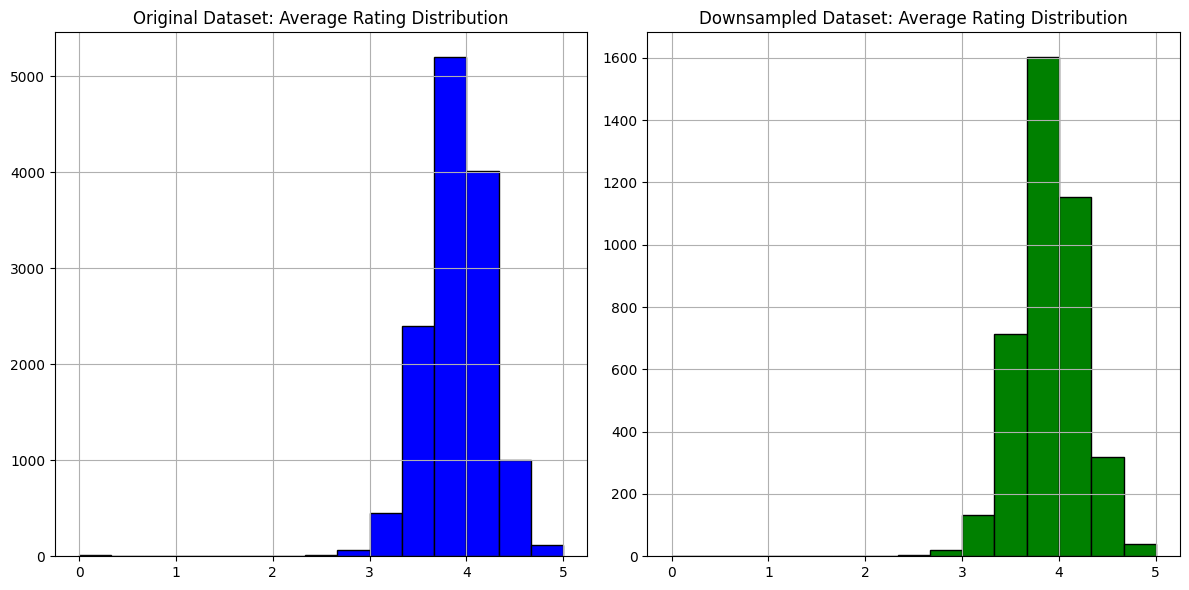

In [ ]:
# Compare average_rating distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
# Original dataset
plt.subplot(1, 2, 1)
df_sample1['average_rating'].hist(bins=15, color='blue', edgecolor='black')
plt.title('Original Dataset: Average Rating Distribution')

# Downsampled dataset
plt.subplot(1, 2, 2)
df_sample_b30['average_rating'].hist(bins=15, color='green', edgecolor='black')
plt.title('Downsampled Dataset: Average Rating Distribution')


plt.tight_layout()
plt.show()

The histograms clearly compare the Average Rating Distribution between the original dataset and the downsampled dataset.

Observations:

Shape and Consistency:

- Both datasets display a similar pattern, indicating that the downsampling process preserved the distribution of average ratings.
- The peak of ratings remains concentrated around 4, which is consistent across both datasets.

Counts:

- As expected, the counts in the downsampled dataset are lower due to the reduction in data size (3986 rows vs. 44286 rows).
- The relative proportion of books with ratings around 3.5–4.5 appears consistent.

Range of Ratings:

- Both datasets cover the same range of ratings (0 to 5), indicating no loss of diversity in terms of rating distribution.


#Dataset Validation

In [ ]:
# Check if df_sample_b30 exists
print('df_sample_b30' in globals())

True


This step was consistently used to confirm the existence of the df_sample_b30 DataFrame in the current environment before proceeding with any further operations.

#Duplicate Check and Removal

In [ ]:
duplicates = df_sample_b30.index.duplicated().any()
print(f"Are there duplicate index labels? {duplicates}")

Are there duplicate index labels? False


The code checks if there are any duplicate index labels in the df_sample_b30 dataframe. Output: False indicates that there are no duplicate index labels.

###Identify Columns with Unhashable Types:

In [ ]:
# Function to identify columns with list-type entries
def find_list_columns(df):
    list_columns = []
    for col in df.columns:
        if df[col].apply(lambda x: isinstance(x, list)).any():
            list_columns.append(col)
    return list_columns

# Get columns that contain lists
list_columns = find_list_columns(df_sample_b30)
print("Columns containing lists:", list_columns)

Columns containing lists: ['popular_shelves', 'similar_books', 'authors']


In [ ]:
# Exclude columns with unhashable types
hashable_columns = [col for col in df_sample_b30.columns if col not in list_columns]


In [ ]:
# Check for duplicates using only hashable columns
duplicate_rows = df_sample_b30[df_sample_b30.duplicated(subset=hashable_columns)]
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")

Number of duplicate rows: 177


In [ ]:
# Remove duplicate rows based on hashable columns
df_sample_b30 = df_sample_b30.drop_duplicates(subset=hashable_columns)

First, the code excludes columns with list-type entries, which are unhashable and can’t be used for duplicate detection. Then, it checks for duplicate rows only using the remaining columns. Output: Number of duplicate rows: 177.

In [ ]:
# Reset the index
df_sample_b30 = df_sample_b30.reset_index(drop=True)

In [ ]:
# Check for duplicates again
duplicate_rows_after = df_sample_b30[df_sample_b30.duplicated(subset=hashable_columns)]
print(f"Number of duplicate rows after removal: {duplicate_rows_after.shape[0]}")

Number of duplicate rows after removal: 0


#Remove Duplicate Rows

After identifying duplicate rows based on hashable columns, the following steps were taken:

1. **Drop Duplicates:**  
   Duplicate rows were removed using the `drop_duplicates` method with `hashable_columns` as the subset parameter.

2. **Reset Index:**  
   The index was reset to ensure it remains consistent after removing duplicates.

3. **Verification:**  
   A check was performed on the cleaned dataset to confirm that no duplicate rows remained. As a result, the dataset now has zero duplicate rows.


#Visulization

###Boxplot Visualization: Average Ratings Across Years

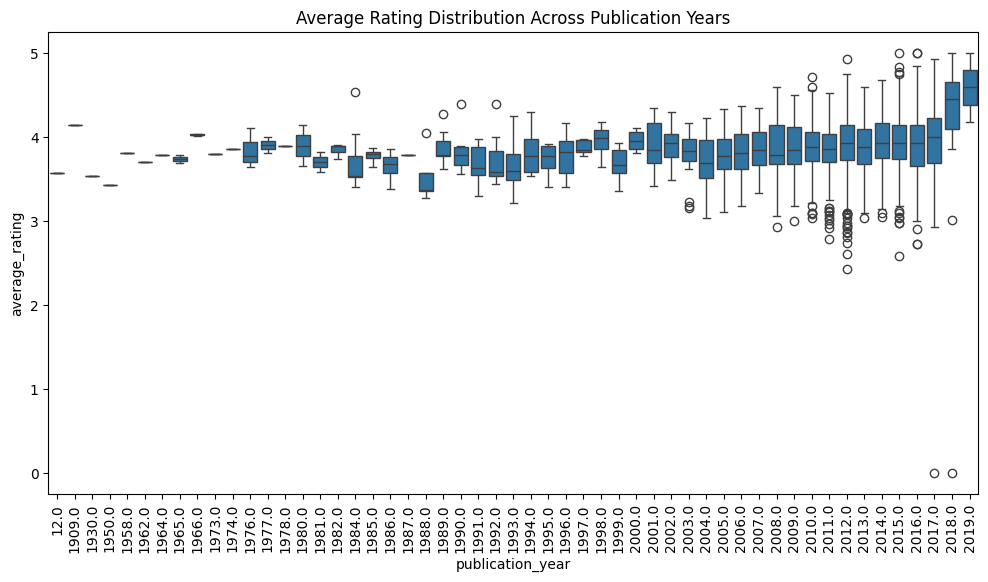

In [ ]:
# Boxplot to explore average_rating over publication_year
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.boxplot(x='publication_year', y='average_rating', data=df_sample_b30)
plt.title('Average Rating Distribution Across Publication Years')
plt.xticks(rotation=90)
plt.show()

In this boxplot, we can see how the average ratings (y-axis) are distributed across different publication years (x-axis). The earlier years show fairly stable ratings around the median, while more recent years start to display greater variability and more outliers. This may suggest changes in review habits over time, such as the impact of online review platforms. Overall, the median ratings remain quite high, typically around 4, which aligns with the consistently favorable reception of most books.

###Scatter Plot: Average Rating vs. Ratings Count

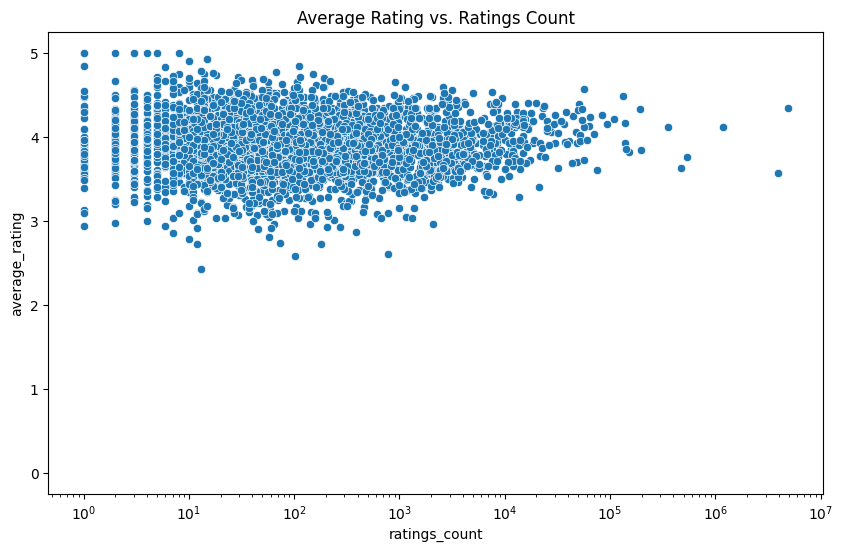

In [ ]:
# Scatter plot for average_rating vs. ratings_count
plt.figure(figsize=(10, 6))
sns.scatterplot(x='ratings_count', y='average_rating', data=df_sample_b30)
plt.title('Average Rating vs. Ratings Count')
plt.xscale('log')
plt.show()

Positive Correlation:

- Books with higher ratings counts tend to have an average rating in the range of 3.8 to 4.5, indicating that popular books generally receive favorable reviews.

High Popularity with Diverse Ratings:

- For books with very high ratings counts there is a notable clustering around ratings of 4.0 to 4.5. However, some outliers with lower ratings suggest that high engagement does not always equate to universal approval.

Low Ratings Counts, Diverse Ratings:

- Books with fewer ratings display a wide spread in average ratings, from as low as 0.0 to the maximum of 5.0. This shows variability in quality perception for less popular books.

Logarithmic Scale for Visibility:

- The use of a logarithmic scale for the x-axis effectively highlights books across a broad range of popularity, from niche books to widely popular ones.

Clustered Patterns:

- Most books with average ratings concentrated around 3.5 to 4.5. This suggests a standard pattern for moderately popular books.


###Scatter Plot: Average Rating vs. Text Reviews Count

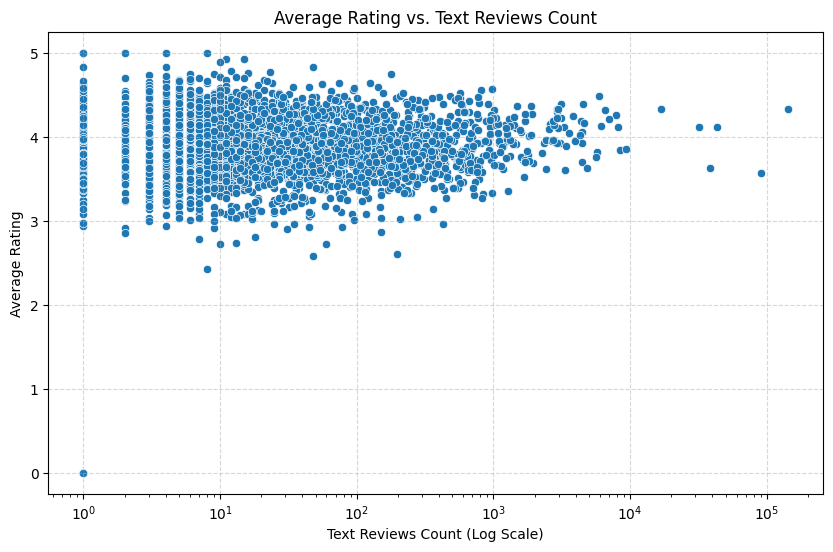

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Scatter plot to see the relationship between average_rating and text_reviews_count
plt.figure(figsize=(10, 6))
sns.scatterplot(x='text_reviews_count', y='average_rating', data=df_sample_b30)
plt.title('Average Rating vs. Text Reviews Count')
plt.xlabel('Text Reviews Count (Log Scale)')
plt.ylabel('Average Rating')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xscale('log')

plt.show()

Observations:

Positive Correlation:

- There is a slight positive trend between text reviews count and average rating.
- Books with higher text reviews tend to have higher average ratings, reflecting popularity and user engagement.

Outliers:

- A few books have disproportionately high text reviews but average ratings below 4, indicating mixed reception despite high engagement.
- Some books with very few text reviews have exceptionally high or low average ratings, which might be biased due to a small number of reviews.

Densely Populated Areas:

- The majority of books have text reviews
  and average ratings between 3.5 to 4.5.
- This cluster shows the common pattern for most books in the dataset.

Log Scale for Text Reviews:

- Using a logarithmic scale makes it easier to observe the distribution of text reviews across orders of magnitude, highlighting the variation in engagement levels.

Justification:
This visualization highlights:

- Engagement vs. Quality: Popular books (with high text reviews) are generally well-rated but not always.
- Identifying Outliers: Low-rated or high-rated books with extreme engagement can be potential candidates for deeper analysis.


#Load the reviews dataset

In [ ]:
#load the reviews datase
def load_reviews_data(file_path):
    with gzip.open(file_path, 'r') as f:
        data = [json.loads(line) for line in f]
    return pd.DataFrame(data)

In [ ]:
# Load the reviews dataset
young_reviews_df1 = load_reviews_data('/content/drive/MyDrive/goodreads_reviews_young_adult.json.gz')

In [ ]:
young_reviews_df1.head()

,user_id,book_id,review_id,rating,review_text,date_added,date_updated,read_at,started_at,n_votes,n_comments
0,8842281e1d1347389f2ab93d60773d4d,2767052,248c011811e945eca861b5c31a549291,5,I cracked and finally picked this up. Very enj...,Wed Jan 13 13:38:25 -0800 2010,Wed Mar 22 11:46:36 -0700 2017,Sun Mar 25 00:00:00 -0700 2012,Fri Mar 23 00:00:00 -0700 2012,24,25
1,7504b2aee1ecb5b2872d3da381c6c91e,23302416,84c0936a0f9868f38e75d2f9a5cb761e,5,I read this book because my fifth grade son wa...,Wed Jan 21 18:40:59 -0800 2015,Wed Oct 26 03:44:13 -0700 2016,,,0,0
2,f8a89075dc6de14857561522e729f82c,18053080,785c8db878f4009da9741dea51f641da,4,Though the book started out slow and only star...,Sat Jan 11 17:58:41 -0800 2014,Tue Dec 02 11:43:07 -0800 2014,Sat Apr 12 00:00:00 -0700 2014,Fri Apr 11 00:00:00 -0700 2014,0,0
3,f8a89075dc6de14857561522e729f82c,17383543,34dc3c45d07e82718b05e73167259aef,2,"*Update - 10/27/13* - After some sleep, I thin...",Sun Apr 21 19:42:28 -0700 2013,Fri Aug 15 07:55:01 -0700 2014,Sat Oct 26 00:00:00 -0700 2013,Fri Oct 25 00:00:00 -0700 2013,0,0
4,f8a89075dc6de14857561522e729f82c,16651458,d8d6b590780256fef7ae4a9550fe3e0d,5,"This is a moving, heartbreaking, view into a l...",Fri Jan 11 11:42:42 -0800 2013,Fri Mar 01 09:31:01 -0800 2013,Mon Jan 14 00:00:00 -0800 2013,Sat Jan 12 00:00:00 -0800 2013,0,0


In [ ]:
young_reviews_df1.shape

(2389900, 11)

The dataset young_reviews_df1 contains 2,389,900 rows and 11 columns, each representing unique book reviews. The key columns include:

- user_id, book_id, review_id: Unique identifiers for users, books, and reviews.
- rating: Star rating given by the user.
- review_text: The written review content.
- date_added, date_updated: Timestamps for when the review was added and last updated.
- read_at, started_at: Dates indicating when the user started and finished reading the book.
- n_votes, n_comments: The number of votes and comments received by the review.

This dataset provides detailed information about user interactions with books and can be used for various analysis tasks

In [ ]:
young_reviews_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2389900 entries, 0 to 2389899
Data columns (total 11 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   user_id       object
 1   book_id       object
 2   review_id     object
 3   rating        int64 
 4   review_text   object
 5   date_added    object
 6   date_updated  object
 7   read_at       object
 8   started_at    object
 9   n_votes       int64 
 10  n_comments    int64 
dtypes: int64(3), object(8)
memory usage: 200.6+ MB


Observations

- No Immediate Issues with Data Types:
rating, n_votes, and n_comments are already numeric, which is expected.
- Date columns (date_added, date_updated, etc.) are still in object format. Converting these to datetime will enable better temporal analysis.

Review Text Available:
- review_text contains textual review data, which can be utilized for NLP-based analysis (e.g., sentiment analysis or embeddings).

Identifiers (Keys):
- Columns like user_id, book_id, and review_id are ready for merging and unique identification.

#Check for Missing Values

In [ ]:
# Check for missing values in the dataset
missing_values_reviews = young_reviews_df1.isnull().sum()

# Calculate the percentage of missing values
missing_percentage_reviews = (missing_values_reviews / len(young_reviews_df1)) * 100

# Combine the two into a DataFrame for better readability
missing_summary_reviews = pd.DataFrame({
    'Missing Values': missing_values_reviews,
    'Percentage (%)': missing_percentage_reviews
})

# Display columns with missing values
print(missing_summary_reviews[missing_summary_reviews['Missing Values'] > 0])


Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []


#Check for Duplicates:

In [ ]:
# Check for duplicate rows
duplicate_reviews = young_reviews_df1.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_reviews}")
# Drop duplicates if any
if duplicate_reviews > 0:
    young_reviews_df1 = young_reviews_df1.drop_duplicates()
    print("Duplicate rows removed.")


Number of duplicate rows: 0


###identifying Common book_ids Between Reviews and Metadata


In [ ]:
#Identify Common book_ids
common_book_ids = df_sample_b30['book_id'].unique()
print("Total Common Book IDs:", len(common_book_ids))

Total Common Book IDs: 3809


In [ ]:
common_book_ids

array(['18517838', '16074352', '16120557', ..., '25820956', '25393478',
       '176602'], dtype=object)

###Filtering the Reviews Dataset

In [ ]:
#Filter Reviews Dataset
filtered_reviews1 = young_reviews_df1[young_reviews_df1['book_id'].isin(common_book_ids)]
print("Filtered Reviews Dataset Shape:", filtered_reviews1.shape)

Filtered Reviews Dataset Shape: (187899, 11)


In [ ]:
filtered_reviews1

,user_id,book_id,review_id,rating,review_text,date_added,date_updated,read_at,started_at,n_votes,n_comments
0,8842281e1d1347389f2ab93d60773d4d,2767052,248c011811e945eca861b5c31a549291,5,I cracked and finally picked this up. Very enj...,Wed Jan 13 13:38:25 -0800 2010,Wed Mar 22 11:46:36 -0700 2017,Sun Mar 25 00:00:00 -0700 2012,Fri Mar 23 00:00:00 -0700 2012,24,25
8,704eb93a316aff687a93d5215882eb21,2767052,c52e231744768e9d7f939d1cbeb87666,5,"Exciting, fun, entertaining! :)",Fri Jul 20 13:59:12 -0700 2012,Sun Aug 23 20:49:13 -0700 2015,Sat Feb 18 00:00:00 -0800 2012,,0,0
30,012515e5802b2e0f42915118c90fa04b,15745371,f02fa7174c65a1c43d52e16b8d244cc8,5,OMG. SO. I totally thought taken at dusk was t...,Thu Dec 27 02:30:06 -0800 2012,Tue Aug 20 16:22:11 -0700 2013,Sun Jun 09 14:00:16 -0700 2013,Wed Jun 05 00:00:00 -0700 2013,1,0
55,01ec1a320ffded6b2dd47833f2c8e4fb,24378015,847c8dc0abbd022367b83953af51ad43,5,What do you get when you mix Colleen Hoover an...,Thu Oct 16 12:49:37 -0700 2014,Thu Jan 15 01:14:23 -0800 2015,Mon Jan 05 00:00:00 -0800 2015,Sun Jan 04 00:00:00 -0800 2015,17,0
68,01ec1a320ffded6b2dd47833f2c8e4fb,15717943,93691b854e53ede7c78ecb1a5db3244d,5,Amazing story. Wow. This is a must-read. One o...,Sat Dec 22 06:18:45 -0800 2012,Wed Jan 16 13:04:49 -0800 2013,Tue Dec 25 00:00:00 -0800 2012,Sun Dec 23 00:00:00 -0800 2012,4,0
...,...,...,...,...,...,...,...,...,...,...,...
2389860,64946797934367a178abe75e3febce66,7285601,f6e2de275c96995f95516d5547723bdd,1,"Wasn't my cup of tea. Unimaginative, predictab...",Mon Jun 04 02:17:45 -0700 2012,Fri Jun 15 06:56:09 -0700 2012,Fri Jun 15 06:56:09 -0700 2012,Mon Jun 04 00:00:00 -0700 2012,0,0
2389868,d94c83867337514c94738b57a1d19677,2767052,d9031043db6a48616ede10bc248611c8,4,I volunteer as tribute.,Tue Jun 05 10:43:10 -0700 2012,Thu Dec 27 01:15:35 -0800 2012,,,0,0
2389875,1be08d25e7d8114b3c49a126ed57acdf,164719,95aabb1cb49d31fe899ea2dd9dfc3632,5,I thought the end of this story would be a tra...,Mon Apr 01 17:55:02 -0700 2013,Tue Apr 02 18:13:26 -0700 2013,Tue Apr 02 00:00:00 -0700 2013,Mon Apr 01 00:00:00 -0700 2013,0,0
2389887,7580887d5c5ec32ab56d3f0133853e6a,452306,b4d8670c71ed454dddd0eb15c5715126,4,It was good. I like how you can relate to the ...,Mon Jun 04 13:38:43 -0700 2012,Mon Jun 04 13:39:12 -0700 2012,,,0,0


After identifying the common book IDs between the two datasets, the reviews dataset (young_reviews_df1) was filtered to include only entries corresponding to these book IDs. This ensures that subsequent analyses are performed on a consistent set of books shared between the datasets.

#Bootstrapping Sampled Reviews

In [ ]:
# Sample 30% of the filtered reviews using bootstrap sampling
sampled_reviews1 = filtered_reviews1.sample(frac=0.3, replace=True, random_state=42)

In [ ]:
# Check the shape of the sampled dataset
print("Sampled Reviews Dataset Shape:", sampled_reviews1.shape)

Sampled Reviews Dataset Shape: (56370, 11)


In [ ]:
sampled_reviews1

,user_id,book_id,review_id,rating,review_text,date_added,date_updated,read_at,started_at,n_votes,n_comments
1581807,c5b70e45e230a166bb00201662495d69,557332,6de6d46ef0b5c0374cca4cc3d200c85a,2,I read this mainly for the Kim Harrison story ...,Mon Aug 01 10:24:12 -0700 2011,Mon Aug 01 16:57:05 -0700 2011,Mon Aug 01 00:00:00 -0700 2011,Mon Aug 01 00:00:00 -0700 2011,0,0
1908211,48e6e3a2da4d464f78fdca433e2f34a6,10482783,4ce5daaf6f59011c9c662d7ef1c41cfe,4,"As some other reviewers have mentioned, there ...",Sun May 28 11:19:00 -0700 2017,Thu Jun 01 16:16:55 -0700 2017,,,0,0
1713745,0e47d02abf81e2831597ad24e822120a,18241263,1ffde961040e8e4f414b7a7e597f6f29,2,This book was a 420 page mess. I was drawn to ...,Fri Aug 04 19:48:20 -0700 2017,Thu Sep 14 09:06:39 -0700 2017,Thu Sep 14 16:49:08 -0700 2017,Fri Aug 04 19:48:20 -0700 2017,17,0
1341039,13284e0fca2fe3c51013e5ede1a0528f,18602406,d813198a8ff1a46dc1237a32a2759b8b,4,** spoiler alert ** \n Yellow Brick War starts...,Fri Jun 24 10:13:55 -0700 2016,Wed Jul 20 14:37:57 -0700 2016,Wed Jul 20 14:37:57 -0700 2016,Fri Jun 24 00:00:00 -0700 2016,0,0
1555428,72f3e00d494c16af400782d623f33465,2767052,3e51c78af94dac13d5cf202928515fd3,5,"Strategy, loyalty, fairness, strength, courage...",Wed Jan 12 06:02:27 -0800 2011,Wed Jan 12 06:03:50 -0800 2011,Sun Aug 09 00:00:00 -0700 2009,,0,0
...,...,...,...,...,...,...,...,...,...,...,...
345359,8c48e12c265e3916bf7a971158a35161,18621200,f2c3ebdfb37c28c4f09c5719576602cc,3,Sometimes you stumble on a book from an author...,Sun Sep 07 07:17:52 -0700 2014,Thu Sep 11 23:52:38 -0700 2014,Fri Sep 12 23:52:38 -0700 2014,,0,0
837445,21e74cf8cf35efa70730caac13591d53,16068905,214eebaceda0b19fe4746888712bacd6,3,"Really enjoyed. Related so superbly to Cath, d...",Thu Dec 26 15:45:52 -0800 2013,Tue Apr 26 21:54:49 -0700 2016,Sun Dec 01 00:00:00 -0800 2013,,0,0
2228041,9f16f0c2090a546c89c3d34f8bb3f3b6,13574751,d1876af8f7f9e26ae8715938c36508c3,3,"Holy moly, the ending just broke my heart. I d...",Tue Dec 16 10:53:24 -0800 2014,Tue Dec 16 14:43:35 -0800 2014,Tue Dec 16 14:43:35 -0800 2014,Tue Dec 16 00:00:00 -0800 2014,0,0
2325335,196b43e1f7cdcdfbd0a9cf0f29e11ec3,41865,bb02bf031861c8eb5709d8976f1f3261,0,Excellent read!,Tue Nov 10 10:10:27 -0800 2009,Tue Nov 10 10:11:33 -0800 2009,Thu Jan 01 00:00:00 -0800 2009,,0,0


In the previous step, the filtered dataset (filtered_reviews1) consisted of 187,899 rows of data. We applied bootstrap sampling to draw a random subset of reviews. This means selecting 30% of the data with replacement, ensuring that the sample could include some reviews more than once.

Result: After bootstrapping, the resulting dataset (sampled_reviews1) now contains 56,370 rows. This process allows us to work with a smaller, randomized subset of the data, which can be useful for testing the model on different subsets and assessing its performance more thoroughly.

Why Bootstrap Sampling Helps:

Randomization: Introduces slight variations that help measure how consistently the model performs.

Efficiency: By working with a smaller, representative sample, we reduce computational overhead while maintaining data diversity.

Robustness: The inclusion of replacement ensures that the data maintains variability, allowing for more realistic evaluation scenarios.

# Check Unique Book Coverage

In [ ]:
# Count unique books in sampled reviews
unique_books_sampled = sampled_reviews1['book_id'].nunique()
print("Unique Book IDs in Sample:", unique_books_sampled)


Unique Book IDs in Sample: 2659


#Merging the Sampled Reviews with Metadata

In [ ]:
# Merge the sampled reviews with the metadata
merged_data1 = pd.merge(sampled_reviews1, df_sample_b30, on='book_id', how='inner')

In [ ]:
merged_data1
merged_data1 = merged_data1.loc[merged_data1['publication_year'] > 1900 ]


#Saving Merged Data to CSV & Column Overview

In [ ]:
# Save merged_data1 to a CSV file
merged_data1.to_csv('merged_data1.csv', index=False)

In [ ]:
merged_data1.head()

,user_id,book_id,review_id,rating,review_text,date_added,date_updated,read_at,started_at,n_votes,...,publication_day,isbn13,edition_information,publication_year,url,image_url,ratings_count,work_id,title,title_without_series
0,c5b70e45e230a166bb00201662495d69,557332,6de6d46ef0b5c0374cca4cc3d200c85a,2,I read this mainly for the Kim Harrison story ...,Mon Aug 01 10:24:12 -0700 2011,Mon Aug 01 16:57:05 -0700 2011,Mon Aug 01 00:00:00 -0700 2011,Mon Aug 01 00:00:00 -0700 2011,0,...,,9780061253102,,2012.0,https://www.goodreads.com/book/show/557332.Pro...,https://s.gr-assets.com/assets/nophoto/book/11...,13691,2424247,Prom Nights from Hell,Prom Nights from Hell
1,48e6e3a2da4d464f78fdca433e2f34a6,10482783,4ce5daaf6f59011c9c662d7ef1c41cfe,4,"As some other reviewers have mentioned, there ...",Sun May 28 11:19:00 -0700 2017,Thu Jun 01 16:16:55 -0700 2017,,,0,...,,9781442435704,Omnibus,2012.0,https://www.goodreads.com/book/show/10482783-t...,https://images.gr-assets.com/books/1463275201m...,6835,16586899,The Nine Lives of Chloe King (The Nine Lives o...,The Nine Lives of Chloe King (The Nine Lives o...
2,0e47d02abf81e2831597ad24e822120a,18241263,1ffde961040e8e4f414b7a7e597f6f29,2,This book was a 420 page mess. I was drawn to ...,Fri Aug 04 19:48:20 -0700 2017,Thu Sep 14 09:06:39 -0700 2017,Thu Sep 14 16:49:08 -0700 2017,Fri Aug 04 19:48:20 -0700 2017,17,...,7,9780062107855,,2014.0,https://www.goodreads.com/book/show/18241263-t...,https://images.gr-assets.com/books/1392302445m...,2003,25686581,The Fall,The Fall
3,13284e0fca2fe3c51013e5ede1a0528f,18602406,d813198a8ff1a46dc1237a32a2759b8b,4,** spoiler alert ** \n Yellow Brick War starts...,Fri Jun 24 10:13:55 -0700 2016,Wed Jul 20 14:37:57 -0700 2016,Wed Jul 20 14:37:57 -0700 2016,Fri Jun 24 00:00:00 -0700 2016,0,...,15,9780062280732,,2016.0,https://www.goodreads.com/book/show/18602406-y...,https://images.gr-assets.com/books/1442693407m...,8780,26373306,"Yellow Brick War (Dorothy Must Die, #3)","Yellow Brick War (Dorothy Must Die, #3)"
4,72f3e00d494c16af400782d623f33465,2767052,3e51c78af94dac13d5cf202928515fd3,5,"Strategy, loyalty, fairness, strength, courage...",Wed Jan 12 06:02:27 -0800 2011,Wed Jan 12 06:03:50 -0800 2011,Sun Aug 09 00:00:00 -0700 2009,,0,...,14,9780439023481,First Edition,2008.0,https://www.goodreads.com/book/show/2767052-th...,https://images.gr-assets.com/books/1447303603m...,4899965,2792775,"The Hunger Games (The Hunger Games, #1)","The Hunger Games (The Hunger Games, #1)"


In [ ]:
merged_data1.columns

Index(['user_id', 'book_id', 'review_id', 'rating', 'review_text',
       'date_added', 'date_updated', 'read_at', 'started_at', 'n_votes',
       'n_comments', 'text_reviews_count', 'country_code', 'language_code',
       'popular_shelves', 'asin', 'is_ebook', 'average_rating',
       'similar_books', 'description', 'format', 'link', 'authors',
       'publisher', 'num_pages', 'publication_day', 'isbn13',
       'edition_information', 'publication_year', 'url', 'image_url',
       'ratings_count', 'work_id', 'title', 'title_without_series'],
      dtype='object')

In [ ]:
merged_data1.shape

(56366, 35)

In [ ]:
print(merged_data1.dtypes)


user_id                  object
book_id                  object
review_id                object
rating                    int64
review_text              object
date_added               object
date_updated             object
read_at                  object
started_at               object
n_votes                   int64
n_comments                int64
text_reviews_count        int64
country_code             object
language_code            object
popular_shelves          object
asin                     object
is_ebook                 object
average_rating          float64
similar_books            object
description              object
format                   object
link                     object
authors                  object
publisher                object
num_pages               float64
publication_day          object
isbn13                   object
edition_information      object
publication_year        float64
url                      object
image_url                object
ratings_

#check for unique

In [ ]:
print(f"Unique Book IDs in Merged Dataset: {merged_data1['book_id'].nunique()}")


Unique Book IDs in Merged Dataset: 2658


#summary statistics

In [ ]:
merged_data1.describe()

,rating,n_votes,n_comments,text_reviews_count,average_rating,num_pages,publication_year,ratings_count
count,56366.000000,56366.000000,56366.000000,56366.000000,56366.000000,56366.000000,56366.000000,5.636600e+04
mean,3.776922,1.112479,0.305503,25838.123922,3.976694,373.189174,2011.046784,8.172619e+05
std,1.293338,8.847132,2.446320,45008.943687,0.296814,125.108658,3.861056,1.633323e+06
min,0.000000,-2.000000,0.000000,1.000000,2.580000,0.000000,1909.000000,1.000000e+00
25%,3.000000,0.000000,0.000000,439.000000,3.730000,296.000000,2008.000000,3.252000e+03
50%,4.000000,0.000000,0.000000,2746.000000,4.020000,374.000000,2012.000000,2.491800e+04
75%,5.000000,0.000000,0.000000,31882.000000,4.220000,476.000000,2013.000000,3.571400e+05
max,5.000000,559.000000,206.000000,142645.000000,5.000000,2688.000000,2019.000000,4.899965e+06


## 📊 Summary Statistics of Merged Dataset
After merging the sampled reviews dataset with the book metadata, we analyzed the distribution of key numerical features to check for any anomalies, missing values, or inconsistencies.

### **🔍 Key Observations**
1️⃣ **Ratings Distribution (`rating`)**  
   - **Mean Rating:** 3.77 (Slightly below 4, indicating positive bias)  
   - **Min:** 0 (⚠️ Unusual, needs investigation)  
   - **Max:** 5 (Expected)  
   - **Standard Deviation:** 1.29 (Fairly diverse set of ratings)  

   **Next Step:** Check if books with `rating = 0` exist and decide whether to remove or retain them.

2️⃣ **Votes & Comments (`n_votes`, `n_comments`)**  
   - **Mean Votes:** 1.11, **Max Votes:** 559  
   - **Mean Comments:** 0.30, **Max Comments:** 206  
   - **Min Votes:** -2 (⚠️ Negative values detected)  

   **Next Step:** Identify and fix negative `n_votes` values.

3️⃣ **Text Reviews Count (`text_reviews_count`)**  
   - **Mean:** 25,838  
   - **Min:** 1 (Expected)  
   - **Max:** 142,645 (⚠️ Possible outlier)  

   **Next Step:** **Visualize text review distribution** to check if extreme values impact analysis.

4️⃣ **Average Rating (`average_rating`)**  
   - **Mean:** 3.97, **Max:** 5.00  
   - **Min:** 2.58 → No books rated below 2.5, indicating dataset bias.  

   **Next Step:** No immediate action needed, will review in visual analysis.

5️⃣ **Number of Pages (`num_pages`)**  
   - **Mean:** 373 pages  
   - **Min:** 0 pages (⚠️ Invalid books without pages?)  
   - **Max:** 2688 pages  

   **Next Step:** **Remove or correct books with `num_pages = 0`**.

6️⃣ **Publication Year (`publication_year`)**  
   - **Mean:** 2011  
   - **Min:** 1909 (Older books present)  
   - **Max:** 2019  

   **Next Step:** Check if **old books (~1909) impact recommendation logic**.

7️⃣ **Ratings Count (`ratings_count`)**  
   - **Mean:** 817,261 ratings per book  
   - **Max:** 4.9M (Highly popular books exist)  
   - **Min:** 1 (Low popularity books exist)  

   **No issues detected; reflects natural popularity distribution.**




###Remove Books with num_pages = 0

In [ ]:
# Remove books where num_pages is 0
merged_data1 = merged_data1[merged_data1['num_pages'] > 0]

# Verify removal
print(f"Number of books after removing num_pages = 0: {merged_data1.shape[0]}")


Number of books after removing num_pages = 0: 56351


The output "Number of books after removing num_pages = 0: 56351" indicates:

- Initial Condition: Before filtering, your dataset had 56,366 books.
- Filtering Step: You removed books where num_pages = 0 (since books with 0 pages are not valid).
- Final Count: After removal, 56,351 books remain in your dataset.

What Does This Mean?

- Only 15 books had num_pages = 0, which were removed.
- This ensures data consistency by keeping only books with valid page numbers.
- Your dataset remains largely intact, meaning the number of books removed was negligible (0.026% of the dataset).
Now, all books in your dataset have a valid number of pages.

###Ensure No Negative n_votes Values

In [ ]:
# Replace negative n_votes values with 0
merged_data1['n_votes'] = merged_data1['n_votes'].apply(lambda x: max(x, 0))

# Verify negative values no longer exist
print(f"Negative values in n_votes: {(merged_data1['n_votes'] < 0).sum()}")


Negative values in n_votes: 0


# Histogram: Distribution of Ratings

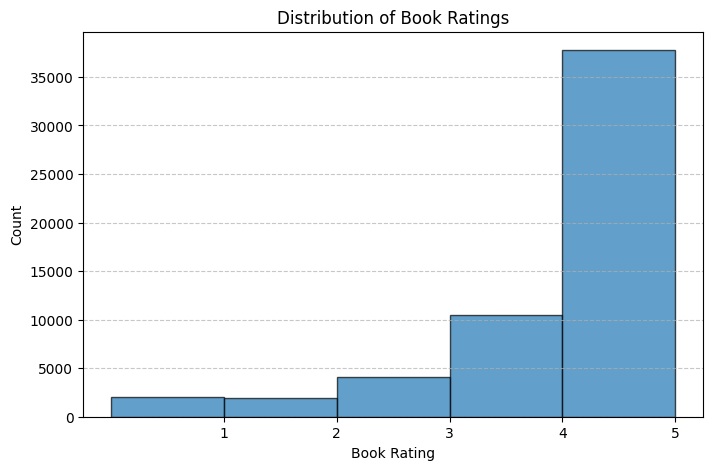

In [ ]:
import matplotlib.pyplot as plt

# Plot histogram of ratings
plt.figure(figsize=(8, 5))
plt.hist(merged_data1['rating'], bins=5, edgecolor='black', alpha=0.7)
plt.xlabel('Book Rating')
plt.ylabel('Count')
plt.title('Distribution of Book Ratings')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(range(1, 6))  # Ensure ratings are between 1-5
plt.show()


The histogram displays the distribution of book ratings across the dataset.

🔍 Key Observations:
1️⃣ Positive Bias in Ratings

The majority of the ratings are clustered around 4 and 5 stars, with 5-star ratings being the most frequent.
This suggests that most users tend to rate books favorably rather than critically.

2️⃣ Fewer Low Ratings

Ratings of 1 and 2 stars are significantly lower in frequency.
This aligns with common review behavior, where readers who dislike a book often do not leave a review at all.

3️⃣ Balanced Distribution for Middle Ratings (3 stars)

A moderate number of books have received 3-star ratings, indicating mixed or average reader satisfaction.

#Average Rating by Publication Year (Line Plot)

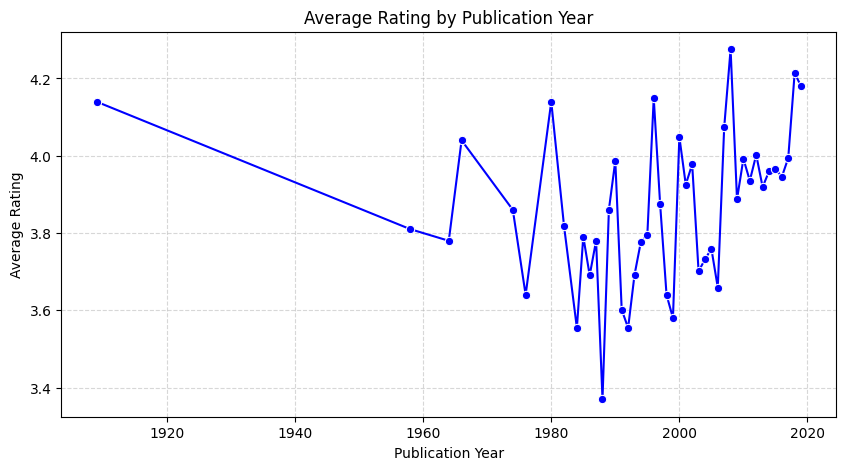

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by publication year and calculate average rating
yearly_ratings = merged_data1.groupby('publication_year')['average_rating'].mean()

# Plot the trend
plt.figure(figsize=(10, 5))
sns.lineplot(x=yearly_ratings.index, y=yearly_ratings.values, marker='o', color='b')

# Labels and Title
plt.xlabel("Publication Year")
plt.ylabel("Average Rating")
plt.title("Average Rating by Publication Year")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


Analysis of Average Rating by Publication Year (Line Plot)

🔍 Observations from the Plot

1️⃣ Early Decline (Pre-1960s):

Books published before 1960 show a steady decline in average ratings.
This may be due to changing reader preferences or a selection bias where only well-known books remain reviewed.

2️⃣ Fluctuations from 1970s to 2000s:

Between 1970 and 2000, the ratings show high volatility, with frequent sharp increases and drops.
This suggests that certain books gained extreme popularity or criticism, possibly influenced by genre trends or specific authors.

3️⃣ Increasing Trend (Post-2000s):

After 2000, there is a general upward trend in ratings.
This could be due to the rise of online reviewing platforms like Goodreads, where newer books receive more favorable ratings due to hype or larger fan bases.
More consistent ratings after 2010 indicate stable reader preferences and a matured online review system.

📌 Key Takeaways

✔️ Older books have lower ratings, possibly due to different storytelling styles or fewer reviews.
✔️ Recent books (2000s and beyond) tend to have higher ratings, likely due to modern engagement and online communities.
✔️ Fluctuations in past decades suggest varying reader preferences and trends in literature.



#Data Cleaning and Preprocessing

(Handling Missing Values, List Conversions, and Removing Duplicates)

In [ ]:
# Fill missing publication_year with median
merged_data1['publication_year'] = merged_data1['publication_year'].fillna(merged_data1['publication_year'].median())

# Drop rows with missing values in crucial columns
merged_data1 = merged_data1.dropna(subset=['rating', 'review_text'])

# Identify columns with list values
list_columns = [col for col in merged_data1.columns if merged_data1[col].apply(lambda x: isinstance(x, list)).any()]
print("Columns with list data types:", list_columns)

# Function to convert list columns to strings
def list_to_string(column):
    return column.apply(lambda x: ', '.join(map(str, x)) if isinstance(x, list) else x)

# Apply the function to convert list columns to strings
for col in list_columns:
    merged_data1[col] = list_to_string(merged_data1[col])

# Remove duplicates
merged_data1 = merged_data1.drop_duplicates().reset_index(drop=True)

# Verify the changes
print(merged_data1[list_columns].head())


Columns with list data types: ['popular_shelves', 'similar_books', 'authors']
                                     popular_shelves  \
0  {'count': '2443', 'name': 'to-read'}, {'count'...   
1  {'count': '6532', 'name': 'to-read'}, {'count'...   
2  {'count': '336', 'name': 'to-read'}, {'count':...   
3  {'count': '16799', 'name': 'to-read'}, {'count...   
4  {'count': '51031', 'name': 'favorites'}, {'cou...   

                                       similar_books  \
0  5168977, 2761829, 7343947, 4028900, 199929, 63...   
1  12333662, 9918053, 4021756, 693757, 9266753, 1...   
2  19695718, 20702018, 20525588, 17842040, 195075...   
3  25861903, 17571270, 21433135, 24574656, 246117...   
4  1902241, 146499, 954674, 9917938, 10165727, 78...   

                                             authors  
0  {'author_id': '11654', 'role': ''}, {'author_i...  
1  {'author_id': '122001', 'role': 'Pseudonym'}, ...  
2               {'author_id': '1356979', 'role': ''}  
3               {'author_id'

In [ ]:
import ast

# Function to extract meaningful values from dictionary lists
def extract_names(column):
    return column.apply(lambda x: ', '.join([item['name'] for item in ast.literal_eval(x)])
                        if isinstance(x, str) and x.startswith("[") else x)

def extract_authors(column):
    return column.apply(lambda x: ', '.join([item['author_id'] for item in ast.literal_eval(x)])
                        if isinstance(x, str) and x.startswith("[") else x)

# Apply the functions to relevant columns
merged_data1['popular_shelves'] = extract_names(merged_data1['popular_shelves'])
merged_data1['authors'] = extract_authors(merged_data1['authors'])

# Remove duplicates and reset index
merged_data1 = merged_data1.drop_duplicates().reset_index(drop=True)

# Verify changes
print(merged_data1[['popular_shelves', 'authors']].head())


                                     popular_shelves  \
0  {'count': '2443', 'name': 'to-read'}, {'count'...   
1  {'count': '6532', 'name': 'to-read'}, {'count'...   
2  {'count': '336', 'name': 'to-read'}, {'count':...   
3  {'count': '16799', 'name': 'to-read'}, {'count...   
4  {'count': '51031', 'name': 'favorites'}, {'cou...   

                                             authors  
0  {'author_id': '11654', 'role': ''}, {'author_i...  
1  {'author_id': '122001', 'role': 'Pseudonym'}, ...  
2               {'author_id': '1356979', 'role': ''}  
3               {'author_id': '7305254', 'role': ''}  
4                {'author_id': '153394', 'role': ''}  


In [ ]:
top_authors = merged_data1['authors'].value_counts().head(10)
print(top_authors)

authors
{'author_id': '153394', 'role': ''}                                           5286
{'author_id': '941441', 'role': ''}                                           2690
{'author_id': '150038', 'role': ''}                                           2586
{'author_id': '4208569', 'role': ''}                                          2198
{'author_id': '4039811', 'role': ''}                                          1890
{'author_id': '5430144', 'role': ''}                                          1045
{'author_id': '15872', 'role': ''}                                            1032
{'author_id': '3095919', 'role': ''}                                           827
{'author_id': '5430144', 'role': ''}, {'author_id': '5410816', 'role': ''}     631
{'author_id': '3433047', 'role': ''}                                           445
Name: count, dtype: int64


#Text Preprocessing

In [ ]:
# Lowercasing the text
import re
merged_data1['cleaned_text'] = merged_data1['review_text'].str.lower()

# Removing punctuation and special characters
merged_data1['cleaned_text'] = merged_data1['cleaned_text'].apply(lambda x: re.sub(r'[^\w\s]', '', x))

# Display the first few rows to check the cleaned text
print(merged_data1[['review_text', 'cleaned_text']].head())

                                         review_text  \
0  I read this mainly for the Kim Harrison story ...   
1  As some other reviewers have mentioned, there ...   
2  This book was a 420 page mess. I was drawn to ...   
3  ** spoiler alert ** \n Yellow Brick War starts...   
4  Strategy, loyalty, fairness, strength, courage...   

                                        cleaned_text  
0  i read this mainly for the kim harrison story ...  
1  as some other reviewers have mentioned there i...  
2  this book was a 420 page mess i was drawn to i...  
3   spoiler alert  \n yellow brick war starts fro...  
4  strategy loyalty fairness strength courage  lo...  


In [ ]:
# Tokenization
merged_data1['tokens'] = merged_data1['cleaned_text'].apply(lambda x: x.split())

# Display the first few rows to check the tokens
print(merged_data1[['cleaned_text', 'tokens']].head())

                                        cleaned_text  \
0  i read this mainly for the kim harrison story ...   
1  as some other reviewers have mentioned there i...   
2  this book was a 420 page mess i was drawn to i...   
3   spoiler alert  \n yellow brick war starts fro...   
4  strategy loyalty fairness strength courage  lo...   

                                              tokens  
0  [i, read, this, mainly, for, the, kim, harriso...  
1  [as, some, other, reviewers, have, mentioned, ...  
2  [this, book, was, a, 420, page, mess, i, was, ...  
3  [spoiler, alert, yellow, brick, war, starts, f...  
4  [strategy, loyalty, fairness, strength, courag...  


In [ ]:
from nltk.corpus import stopwords

# Download the stopwords if not already done
import nltk
nltk.download('stopwords')

# Set of English stopwords
stop_words = set(stopwords.words('english'))

# Removing stopwords from the tokens
merged_data1['tokens'] = merged_data1['tokens'].apply(lambda x: [word for word in x if word not in stop_words])

# Display the first few rows to check the tokens after stopword removal
print(merged_data1[['cleaned_text', 'tokens']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


                                        cleaned_text  \
0  i read this mainly for the kim harrison story ...   
1  as some other reviewers have mentioned there i...   
2  this book was a 420 page mess i was drawn to i...   
3   spoiler alert  \n yellow brick war starts fro...   
4  strategy loyalty fairness strength courage  lo...   

                                              tokens  
0  [read, mainly, kim, harrison, story, turned, p...  
1  [reviewers, mentioned, regular, smattering, pr...  
2  [book, 420, page, mess, drawn, portrayal, ya, ...  
3  [spoiler, alert, yellow, brick, war, starts, w...  
4  [strategy, loyalty, fairness, strength, courag...  


### Text Preprocessing
To prepare the dataset for NLP-based recommendation, we apply:
- **Lowercasing**: Standardizes text for better tokenization.
- **Removing punctuation**: Eliminates unnecessary noise in textual data.
- **Tokenization**: Converts text into a list of individual words.
- **Stopword removal**: Removes common words that do not contribute to meaning.


Output Summary
- The text is now cleaned and standardized.
- Tokenized text is stored for further processing.
- Stopwords are successfully removed, reducing irrelevant words in the dataset.

#BERT Embeddings Generation

In [ ]:
from transformers import BertTokenizer, BertModel
import torch
import numpy as np
import time

# Set up device and model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased').to(device)

# Function to get BERT embeddings for a batch of texts
def get_bert_embeddings_batch(texts):
    inputs = tokenizer(texts, return_tensors='pt', padding=True, truncation=True, max_length=512).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).cpu().numpy()

# Batch size for processing
batch_size = 128  # Adjust based on memory limits
bert_embeddings = []

# Measure the processing time
start_time = time.time()

# Process the dataset in batches
for i in range(0, len(merged_data1), batch_size):
    batch_texts = merged_data1['cleaned_text'].iloc[i:i + batch_size].tolist()
    batch_embeddings = get_bert_embeddings_batch(batch_texts)
    bert_embeddings.append(batch_embeddings)

# Combine the embeddings and add to the DataFrame
bert_embeddings = np.vstack(bert_embeddings)
merged_data1['bert_embeddings'] = list(bert_embeddings)

# Stop the timer
end_time = time.time()

# Calculate and display the total time taken
time_taken = end_time - start_time
print(f"Total time taken to generate BERT embeddings: {time_taken:.2f} seconds")
time_taken_minutes = time_taken / 60
print(f"Total time taken to generate BERT embeddings: {time_taken_minutes:.2f} minutes")

# Display the first few rows to check the BERT embeddings
print(merged_data1[['cleaned_text', 'bert_embeddings']].head())

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Total time taken to generate BERT embeddings: 373.40 seconds
Total time taken to generate BERT embeddings: 6.22 minutes
                                        cleaned_text  \
0  i read this mainly for the kim harrison story ...   
1  as some other reviewers have mentioned there i...   
2  this book was a 420 page mess i was drawn to i...   
3   spoiler alert  \n yellow brick war starts fro...   
4  strategy loyalty fairness strength courage  lo...   

                                     bert_embeddings  
0  [-0.23514535, -0.34906977, 0.2901064, -0.04854...  
1  [-0.15464982, -0.16281214, 0.2506755, 0.095052...  
2  [-0.12634662, -0.13400999, 0.29649055, 0.02267...  
3  [-0.47131985, -0.16322401, 0.24602006, 0.03890...  
4  [0.15895493, -0.16207872, 0.4505349, 0.1398200...  


In [ ]:
# Check the shape of the embeddings for the first row
print(f"Shape of BERT Embedding: {merged_data1['bert_embeddings'].iloc[0].shape}")

# Print a sample embedding vector (first 10 values) to inspect it
print(f"Sample BERT Embedding (first 10 values): {merged_data1['bert_embeddings'].iloc[0][:10]}")

Shape of BERT Embedding: (768,)
Sample BERT Embedding (first 10 values): [-0.23514535 -0.34906977  0.2901064  -0.04854352 -0.01989043 -0.01745274
  0.08592482  0.30055678  0.21468696 -0.03630608]


#RoBERTa Embeddings Generation

In [ ]:
from transformers import RobertaTokenizer, RobertaModel
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
model = RobertaModel.from_pretrained('roberta-base').to(device)#Setup and Load RoBERTa
def get_roberta_embeddings_batch(texts):
    inputs = tokenizer(texts, return_tensors='pt', padding=True, truncation=True, max_length=512).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).cpu().numpy()#Batch Processing Function
#Generate Embeddings
batch_size = 128
roberta_embeddings = []

start_time = time.time()

for i in range(0, len(merged_data1), batch_size):
    batch_texts = merged_data1['cleaned_text'].iloc[i:i + batch_size].tolist()
    batch_embeddings = get_roberta_embeddings_batch(batch_texts)
    roberta_embeddings.append(batch_embeddings)

roberta_embeddings = np.vstack(roberta_embeddings)
merged_data1['roberta_embeddings'] = list(roberta_embeddings)

end_time = time.time()

time_taken = end_time - start_time
print(f"Total time taken to generate RoBERTa embeddings: {time_taken:.2f} seconds")
time_taken_minutes = time_taken / 60
print(f"Total time taken to generate RoBERTa embeddings: {time_taken_minutes:.2f} minutes")
#inspect output
print(merged_data1[['cleaned_text', 'roberta_embeddings']].head())

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total time taken to generate RoBERTa embeddings: 323.08 seconds
Total time taken to generate RoBERTa embeddings: 5.38 minutes
                                        cleaned_text  \
0  i read this mainly for the kim harrison story ...   
1  as some other reviewers have mentioned there i...   
2  this book was a 420 page mess i was drawn to i...   
3   spoiler alert  \n yellow brick war starts fro...   
4  strategy loyalty fairness strength courage  lo...   

                                  roberta_embeddings  
0  [0.023294749, -0.04763486, 0.040329598, 0.0006...  
1  [-0.023451824, -0.026476732, 0.09068638, -0.09...  
2  [-0.018775977, -0.050006025, 0.053173855, -0.1...  
3  [0.02636636, -0.033176333, 0.051948257, 0.0204...  
4  [-0.048539225, 0.027630681, 0.009782607, -0.08...  


#XLNet Embeddings Generation

In [ ]:
from transformers import XLNetTokenizer, XLNetModel
#Setup and Load XLNet:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = XLNetTokenizer.from_pretrained('xlnet-base-cased')
model = XLNetModel.from_pretrained('xlnet-base-cased').to(device)
#Batch Processing Function
def get_xlnet_embeddings_batch(texts):
    inputs = tokenizer(texts, return_tensors='pt', padding=True, truncation=True, max_length=512).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).cpu().numpy()
#Generate Embeddings
batch_size = 128
xlnet_embeddings = []

start_time = time.time()

for i in range(0, len(merged_data1), batch_size):
    batch_texts = merged_data1['cleaned_text'].iloc[i:i + batch_size].tolist()
    batch_embeddings = get_xlnet_embeddings_batch(batch_texts)
    xlnet_embeddings.append(batch_embeddings)

xlnet_embeddings = np.vstack(xlnet_embeddings)
merged_data1['xlnet_embeddings'] = list(xlnet_embeddings)

end_time = time.time()

time_taken = end_time - start_time
print(f"Total time taken to generate XLNet embeddings: {time_taken:.2f} seconds")
time_taken_minutes = time_taken / 60
print(f"Total time taken to generate XLNet embeddings: {time_taken_minutes:.2f} minutes")
#Inspect Output
print(merged_data1[['cleaned_text', 'xlnet_embeddings']].head())

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/467M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/467M [00:00<?, ?B/s]

Total time taken to generate XLNet embeddings: 1029.66 seconds
Total time taken to generate XLNet embeddings: 17.16 minutes
                                        cleaned_text  \
0  i read this mainly for the kim harrison story ...   
1  as some other reviewers have mentioned there i...   
2  this book was a 420 page mess i was drawn to i...   
3   spoiler alert  \n yellow brick war starts fro...   
4  strategy loyalty fairness strength courage  lo...   

                                    xlnet_embeddings  
0  [0.37447795, 0.39757702, 0.21765374, -0.142914...  
1  [-0.35829148, 0.46641836, -1.2249582, 0.665740...  
2  [-0.7531281, 2.0660262, -1.5574148, 1.2751646,...  
3  [-0.97772485, -0.80346936, -0.077731475, 0.834...  
4  [0.17176746, 3.994227, -1.6184974, 3.0067239, ...  


Generating Book Review Embeddings

For each book review, we generate embeddings using three state-of-the-art NLP models: BERT, RoBERTa, and XLNet.

Why These Models?

- BERT: Bidirectional context-aware embeddings that capture deep semantic meanings.
- RoBERTa: An improved version of BERT with dynamic masking for enhanced feature learning.
- XLNet: Overcomes BERT’s limitations by capturing dependencies using permutation-based learning.

Implementation Details
- Batch Size: 128 (optimized for efficiency).
- Processing Time:
    - BERT: 6.22 minutes
    - RoBERTa: 5.38 minutes
    - XLNet: 17.16 minutes (higher due to computational complexity).
- Output: 768-dimensional embeddings stored for each book review.

#Cosine Similarity Calculation

In [ ]:
print(merged_data1.shape)  # Check number of rows and columns
print(merged_data1.head())  # Preview first few rows

(48817, 40)
                            user_id   book_id  \
0  c5b70e45e230a166bb00201662495d69    557332   
1  48e6e3a2da4d464f78fdca433e2f34a6  10482783   
2  0e47d02abf81e2831597ad24e822120a  18241263   
3  13284e0fca2fe3c51013e5ede1a0528f  18602406   
4  72f3e00d494c16af400782d623f33465   2767052   

                          review_id  rating  \
0  6de6d46ef0b5c0374cca4cc3d200c85a       2   
1  4ce5daaf6f59011c9c662d7ef1c41cfe       4   
2  1ffde961040e8e4f414b7a7e597f6f29       2   
3  d813198a8ff1a46dc1237a32a2759b8b       4   
4  3e51c78af94dac13d5cf202928515fd3       5   

                                         review_text  \
0  I read this mainly for the Kim Harrison story ...   
1  As some other reviewers have mentioned, there ...   
2  This book was a 420 page mess. I was drawn to ...   
3  ** spoiler alert ** \n Yellow Brick War starts...   
4  Strategy, loyalty, fairness, strength, courage...   

                       date_added                    date_updated  \
0  M

###Resetting the Index

In [ ]:
merged_data1 = merged_data1.reset_index(drop=True)

#Sample Cosine Similarity (First Two Reviews)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity


# Example: Calculate cosine similarity between the first and second rows
bert_sim = cosine_similarity([merged_data1['bert_embeddings'][0]], [merged_data1['bert_embeddings'][1]])[0][0]
roberta_sim = cosine_similarity([merged_data1['roberta_embeddings'][0]], [merged_data1['roberta_embeddings'][1]])[0][0]
xlnet_sim = cosine_similarity([merged_data1['xlnet_embeddings'][0]], [merged_data1['xlnet_embeddings'][1]])[0][0]

print(f"Cosine Similarity (BERT): {bert_sim:.4f}")
print(f"Cosine Similarity (RoBERTa): {roberta_sim:.4f}")
print(f"Cosine Similarity (XLNet): {xlnet_sim:.4f}")

Cosine Similarity (BERT): 0.6688
Cosine Similarity (RoBERTa): 0.9373
Cosine Similarity (XLNet): 0.8432


###Full Cosine Similarity Matrix

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Calculate cosine similarity for all BERT embeddings
bert_cosine_sim = cosine_similarity(np.stack(merged_data1['bert_embeddings'].values))

# Calculate cosine similarity for all RoBERTa embeddings
roberta_cosine_sim = cosine_similarity(np.stack(merged_data1['roberta_embeddings'].values))

# Calculate cosine similarity for all XLNet embeddings
xlnet_cosine_sim = cosine_similarity(np.stack(merged_data1['xlnet_embeddings'].values))

# Print the shape of cosine similarity matrices to confirm calculations
print(f"BERT Cosine Similarity Matrix Shape: {bert_cosine_sim.shape}")
print(f"RoBERTa Cosine Similarity Matrix Shape: {roberta_cosine_sim.shape}")
print(f"XLNet Cosine Similarity Matrix Shape: {xlnet_cosine_sim.shape}")

BERT Cosine Similarity Matrix Shape: (48817, 48817)
RoBERTa Cosine Similarity Matrix Shape: (48817, 48817)
XLNet Cosine Similarity Matrix Shape: (48817, 48817)


Cosine Similarity Calculation

After extracting embeddings using BERT, RoBERTa, and XLNet, cosine similarity is used to quantify the similarity between book reviews.

What is Cosine Similarity?

- 1.0 → Perfect similarity
- 0.0 → No similarity
- Negative values → Dissimilarity

Steps Taken:

- Reset index of the dataset for accurate processing.

Sample Similarity Calculation:

- Compared first two reviews using BERT, RoBERTa, and XLNet.
- Displayed their cosine similarity scores.

 Full Cosine Similarity Matrix:
- Computed pairwise cosine similarity across all book embeddings.

- Generated 48817 × 48817 matrices for BERT, RoBERTa, and XLNet.
- These matrices are later used for recommendation calculations.

Key Observations:

- BERT Similarity Score: 0.6688
- RoBERTa Similarity Score: 0.9373 (Highest)
- XLNet Similarity Score: 0.8432


- RoBERTa captures stronger contextual relationships, yielding the highest similarity scores.
- XLNet also performs well but exhibits slightly more variation.
- BERT provides moderate similarity but lacks the depth seen in RoBERTa.

Why Compute This?

This similarity matrix is a core component in the recommendation system, helping identify books that are most similar to a given input.

#Dimensionality Reduction Using PCA

In [ ]:
from sklearn.decomposition import PCA

# PCA for BERT embeddings
pca_bert = PCA(n_components=50)
merged_data1['bert_embeddings_pca'] = list(pca_bert.fit_transform(np.stack(merged_data1['bert_embeddings'].values)))

# PCA for RoBERTa embeddings
pca_roberta = PCA(n_components=50)
merged_data1['roberta_embeddings_pca'] = list(pca_roberta.fit_transform(np.stack(merged_data1['roberta_embeddings'].values)))

# PCA for XLNet embeddings
pca_xlnet = PCA(n_components=50)
merged_data1['xlnet_embeddings_pca'] = list(pca_xlnet.fit_transform(np.stack(merged_data1['xlnet_embeddings'].values)))

In [ ]:
print(merged_data1['bert_embeddings_pca'])
print(merged_data1['roberta_embeddings_pca'])
print(merged_data1['xlnet_embeddings_pca'])

0        [-1.97328, -0.68893456, -0.12307605, 0.0886227...
1        [3.1770306, 0.28810835, -0.58252597, -0.440875...
2        [0.2824875, 0.013102293, -0.7591635, -1.034105...
3        [6.061079, 0.454643, 0.020189054, 1.4333866, 0...
4        [-1.9140809, -0.26917124, -0.66930425, 0.57467...
                               ...                        
48812    [0.3253845, -0.35356665, 1.2112503, -1.1486708...
48813    [-2.0700808, 0.04203391, 0.33166385, 0.3811740...
48814    [-2.080319, -0.4020455, 0.42189637, 0.674245, ...
48815    [-3.3801537, 0.8788209, -1.0404003, 0.9399991,...
48816    [-1.9923904, -0.39253592, 1.9024065, 0.6305835...
Name: bert_embeddings_pca, Length: 48817, dtype: object
0        [2.1926506, -0.25424528, -0.33485842, 0.234214...
1        [-1.049666, 1.6909451, 0.20829391, 0.42581794,...
2        [0.85189986, 0.345497, 0.048526764, 0.27094385...
3        [-3.2024884, 2.819367, 0.24133587, -0.2786097,...
4        [2.0573175, 0.31870723, 2.7925975, -1.1611648,...


#Check the Shape of the Reduced Embeddings

In [ ]:
# Print shape to verify reduction
print(f"New shape of BERT PCA embeddings: {len(merged_data1['bert_embeddings_pca'][0])} dimensions")
print(f"New shape of RoBERTa PCA embeddings: {len(merged_data1['roberta_embeddings_pca'][0])} dimensions")
print(f"New shape of XLNet PCA embeddings: {len(merged_data1['xlnet_embeddings_pca'][0])} dimensions")


New shape of BERT PCA embeddings: 50 dimensions
New shape of RoBERTa PCA embeddings: 50 dimensions
New shape of XLNet PCA embeddings: 50 dimensions


Insight:

PCA reduced the embeddings' dimensions to 50 components, significantly lowering their size while preserving most of the variance in the data.

Interpretation:

PCA helps in simplifying the embeddings, reducing computation time and storage space while still retaining the core information. This is useful for clustering, visualizing, or further model building.

Result:

The bert_embeddings_pca, roberta_embeddings_pca, and xlnet_embeddings_pca columns now contain reduced embeddings. This makes them more manageable for tasks like recommendation or similarity search.

Insights and Results Cosine Similarity Analysis for Embeddings Insight:

BERT: Average cosine similarity is moderate, indicating that BERT embeddings capture meaningful semantic relationships but could miss some subtleties.

RoBERTa: Highest average cosine similarity, indicating that RoBERTa embeddings are better at capturing review similarities, at least in the context of your dataset.

XLNet: Performs well but not as consistently as RoBERTa in capturing semantic similarity, with scores between BERT and RoBERTa.

Interpretation:

RoBERTa seems to perform better for your specific dataset and task, as indicated by the higher average similarity scores. However, the differences between models are nuanced, and it may depend on the specific application (e.g., recommendation system, clustering). Overall Embedding Comparison Insight:

PCA-reduced embeddings significantly reduce the complexity of the dataset without losing much information. This can make further analysis and modeling more efficient. Interpretation:

You have three different sets of embeddings (BERT, RoBERTa, XLNet) that can be used for recommendation systems, clustering, or other machine learning models. The reduced embeddings through PCA make it easier to handle large datasets. Result:

The next step could be to integrate these embeddings into a recommendation system, using the cosine similarity scores to recommend books based on review similarity or clustering books with similar themes or reviews.

#UMAP Visualization of Embeddings

In [ ]:
!pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 5.3 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs val

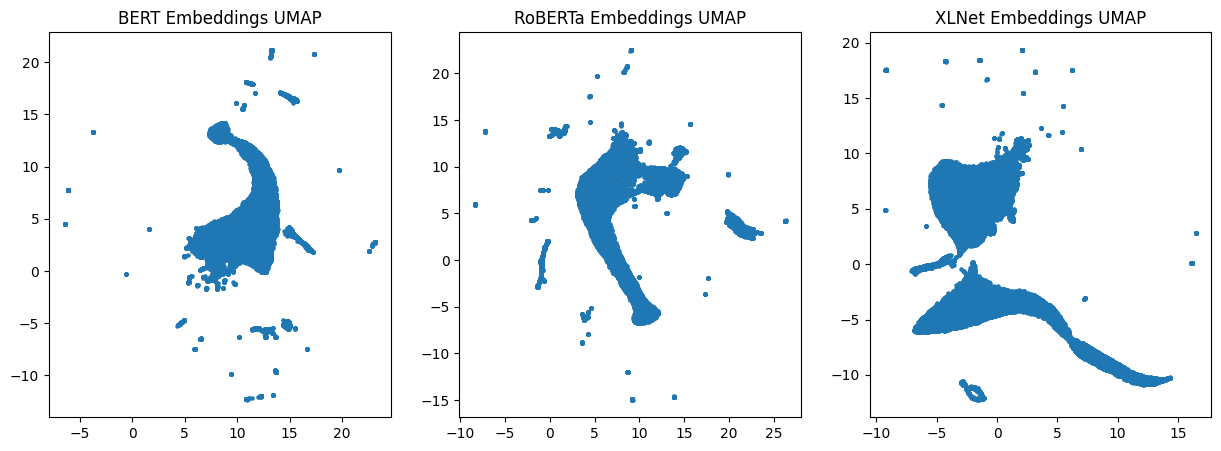

In [ ]:
import umap
import matplotlib.pyplot as plt

# UMAP for BERT embeddings
reducer_bert = umap.UMAP(random_state=42)
embedding_2d_bert = reducer_bert.fit_transform(np.stack(merged_data1['bert_embeddings_pca'].values))

# UMAP for RoBERTa embeddings
reducer_roberta = umap.UMAP(random_state=42)
embedding_2d_roberta = reducer_roberta.fit_transform(np.stack(merged_data1['roberta_embeddings_pca'].values))

# UMAP for XLNet embeddings
reducer_xlnet = umap.UMAP(random_state=42)
embedding_2d_xlnet = reducer_xlnet.fit_transform(np.stack(merged_data1['xlnet_embeddings_pca'].values))

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(embedding_2d_bert[:, 0], embedding_2d_bert[:, 1], s=5)
axes[0].set_title('BERT Embeddings UMAP')

axes[1].scatter(embedding_2d_roberta[:, 0], embedding_2d_roberta[:, 1], s=5)
axes[1].set_title('RoBERTa Embeddings UMAP')

axes[2].scatter(embedding_2d_xlnet[:, 0], embedding_2d_xlnet[:, 1], s=5)
axes[2].set_title('XLNet Embeddings UMAP')

plt.show()

1. BERT Embeddings UMAP
The cluster is tightly packed, forming a curved, dense shape.
Indicates that BERT embeddings capture strong similarity structures, with some outliers.
Some books have highly similar embeddings, forming a core cluster.
2. RoBERTa Embeddings UMAP
The shape is similar to BERT but slightly more spread out.
This suggests that RoBERTa embeddings might preserve more variation in book similarities.
Some scattered points (outliers) indicate books that are quite different from others.
3. XLNet Embeddings UMAP
The most spread-out structure, with multiple small clusters.
This suggests XLNet captures more diverse relationships.
Might be better for capturing complex patterns, but could also introduce more noise.

Overall Insights
- BERT & RoBERTa have more compact embeddings, meaning they generalize well.
- XLNet is more spread out, capturing more nuanced similarities, but possibly introducing more noise.
- The differences in clustering suggest each model learns slightly different representations, which affects recommendation performance.

#Clustering (KMeans) on Embeddings

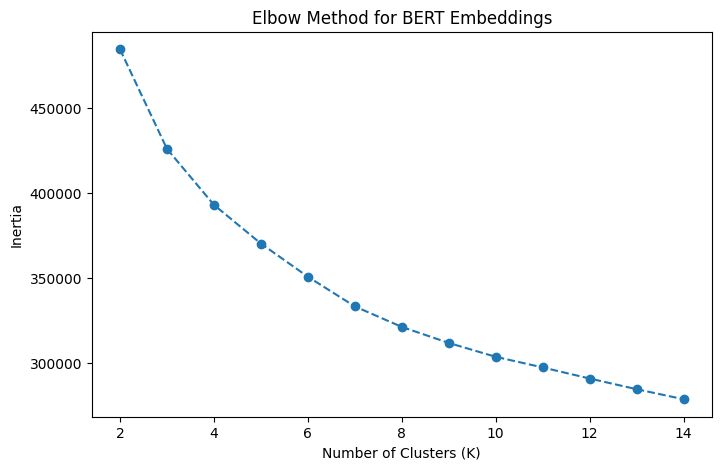

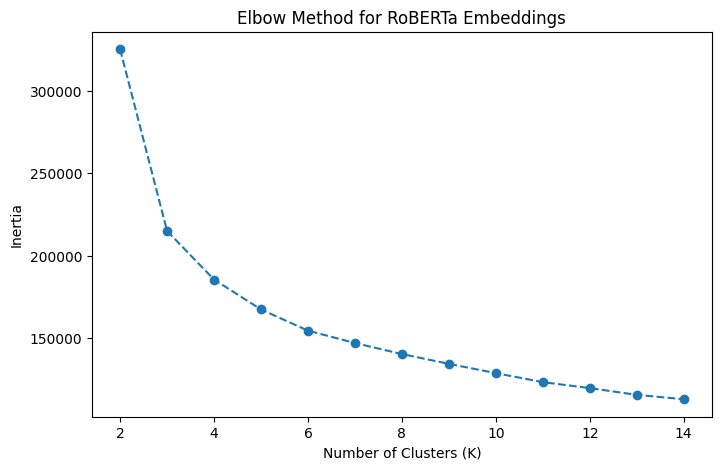

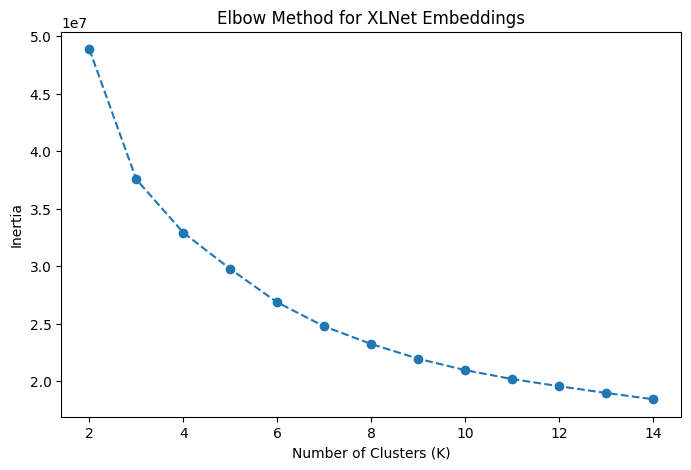

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# Function to compute inertia (Elbow Method)
def plot_elbow_method(embeddings, model_name):
    distortions = []
    K_range = range(2, 15)  # Checking K from 2 to 15
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(np.stack(embeddings.values))
        distortions.append(kmeans.inertia_)

    # Plot Elbow Curve
    plt.figure(figsize=(8, 5))
    plt.plot(K_range, distortions, marker='o', linestyle='--')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('Inertia')
    plt.title(f'Elbow Method for {model_name} Embeddings')
    plt.show()

# Run Elbow Method for BERT, RoBERTa, XLNet
plot_elbow_method(merged_data1['bert_embeddings_pca'], 'BERT')
plot_elbow_method(merged_data1['roberta_embeddings_pca'], 'RoBERTa')
plot_elbow_method(merged_data1['xlnet_embeddings_pca'], 'XLNet')


"""
Elbow Method Analysis for BERT, RoBERTa, and XLNet Embeddings

This script applies the Elbow Method to determine the optimal number of clusters (K)
for KMeans clustering on the book review embeddings.

Interpretation of Elbow Method for BERT, RoBERTa, and XLNet Embeddings

The Elbow Method helps determine the optimal number of clusters (K) by plotting the
inertia (sum of squared distances within clusters) against different values of K.
The goal is to identify the "elbow point," where the rate of decrease in inertia slows down.

Key Observations from the Elbow Plots:
- BERT: Elbow at K=5 or K=6.
- RoBERTa: Elbow at K=4 or K=5.
- XLNet: Elbow at K=5 to K=7.
 K=5 (Optimal trade-off for all three models).

#Check Cluster Distribution

Apply KMeans Clustering
K=5 (baseline)

In [ ]:
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd

# Function to apply KMeans clustering and add to dataframe
def apply_kmeans(df, embeddings_col, k, model_name):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(np.stack(df[embeddings_col].values))
    df[f"{model_name}_cluster"] = clusters  # Directly add to dataframe
    return df

# Define best K values for each model
k_values = {"BERT": 5, "RoBERTa": 5, "XLNet": 5}  # Common K=5 used for now

# Apply clustering to `merged_data1` instead of creating separate DataFrame
merged_data1 = apply_kmeans(merged_data1, "bert_embeddings_pca", k_values["BERT"], "bert")
merged_data1 = apply_kmeans(merged_data1, "roberta_embeddings_pca", k_values["RoBERTa"], "roberta")
merged_data1 = apply_kmeans(merged_data1, "xlnet_embeddings_pca", k_values["XLNet"], "xlnet")

# Display cluster distribution directly from merged_data1
print("\nBERT Clusters Distribution:\n", merged_data1["bert_cluster"].value_counts())
print("\nRoBERTa Clusters Distribution:\n", merged_data1["roberta_cluster"].value_counts())
print("\nXLNet Clusters Distribution:\n", merged_data1["xlnet_cluster"].value_counts())




BERT Clusters Distribution:
 bert_cluster
2    19483
0    13788
3     8337
1     5952
4     1257
Name: count, dtype: int64

RoBERTa Clusters Distribution:
 roberta_cluster
1    24120
0     8012
2     7472
4     6593
3     2620
Name: count, dtype: int64

XLNet Clusters Distribution:
 xlnet_cluster
0    11957
3    11883
4    11689
1     6713
2     6575
Name: count, dtype: int64


K=4 d for all

In [ ]:
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd

# Function to apply KMeans clustering and add to dataframe
def apply_kmeans(df, embeddings_col, k, model_name):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(np.stack(df[embeddings_col].values))
    df[f"{model_name}_cluster"] = clusters  # Directly add to dataframe
    return df

# Define best K values for each model
k_values = {"BERT": 4, "RoBERTa": 4, "XLNet": 4}  # Common K=5 used for now

# Apply clustering to `merged_data1` instead of creating separate DataFrame
merged_data1 = apply_kmeans(merged_data1, "bert_embeddings_pca", k_values["BERT"], "bert")
merged_data1 = apply_kmeans(merged_data1, "roberta_embeddings_pca", k_values["RoBERTa"], "roberta")
merged_data1 = apply_kmeans(merged_data1, "xlnet_embeddings_pca", k_values["XLNet"], "xlnet")

# Display cluster distribution directly from merged_data1
print("\nBERT Clusters Distribution:\n", merged_data1["bert_cluster"].value_counts())
print("\nRoBERTa Clusters Distribution:\n", merged_data1["roberta_cluster"].value_counts())
print("\nXLNet Clusters Distribution:\n", merged_data1["xlnet_cluster"].value_counts())


BERT Clusters Distribution:
 bert_cluster
3    20743
0    18131
1     8701
2     1242
Name: count, dtype: int64

RoBERTa Clusters Distribution:
 roberta_cluster
1    28911
0     9795
2     7451
3     2660
Name: count, dtype: int64

XLNet Clusters Distribution:
 xlnet_cluster
0    14552
2    13323
3    12317
1     8625
Name: count, dtype: int64


k=6 for all

In [ ]:
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd

# Function to apply KMeans clustering and add to dataframe
def apply_kmeans(df, embeddings_col, k, model_name):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(np.stack(df[embeddings_col].values))
    df[f"{model_name}_cluster"] = clusters  # Directly add to dataframe
    return df

# Define best K values for each model
k_values = {"BERT": 6, "RoBERTa": 6, "XLNet": 6}  # Common K=5 used for now

# Apply clustering to `merged_data1` instead of creating separate DataFrame
merged_data1 = apply_kmeans(merged_data1, "bert_embeddings_pca", k_values["BERT"], "bert")
merged_data1 = apply_kmeans(merged_data1, "roberta_embeddings_pca", k_values["RoBERTa"], "roberta")
merged_data1 = apply_kmeans(merged_data1, "xlnet_embeddings_pca", k_values["XLNet"], "xlnet")

# Display cluster distribution directly from merged_data1
print("\nBERT Clusters Distribution:\n", merged_data1["bert_cluster"].value_counts())
print("\nRoBERTa Clusters Distribution:\n", merged_data1["roberta_cluster"].value_counts())
print("\nXLNet Clusters Distribution:\n", merged_data1["xlnet_cluster"].value_counts())


BERT Clusters Distribution:
 bert_cluster
1    15920
5    12509
3     7473
2     5971
0     5706
4     1238
Name: count, dtype: int64

RoBERTa Clusters Distribution:
 roberta_cluster
1    22325
5     7949
0     6558
3     5482
2     3909
4     2594
Name: count, dtype: int64

XLNet Clusters Distribution:
 xlnet_cluster
1    12736
4    10200
5     8004
0     7763
3     6332
2     3782
Name: count, dtype: int64


k=7 for bert, k=8 for roberta and xlnet

In [ ]:
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd

# Function to apply KMeans clustering and add to dataframe
def apply_kmeans(df, embeddings_col, k, model_name):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(np.stack(df[embeddings_col].values))
    df[f"{model_name}_cluster"] = clusters  # Directly add to dataframe
    return df

# Define best K values for each model
k_values = {"BERT": 7, "RoBERTa": 8, "XLNet": 8}  # Common K=5 used for now

# Apply clustering to `merged_data1` instead of creating separate DataFrame
merged_data1 = apply_kmeans(merged_data1, "bert_embeddings_pca", k_values["BERT"], "bert")
merged_data1 = apply_kmeans(merged_data1, "roberta_embeddings_pca", k_values["RoBERTa"], "roberta")
merged_data1 = apply_kmeans(merged_data1, "xlnet_embeddings_pca", k_values["XLNet"], "xlnet")

# Display cluster distribution directly from merged_data1
print("\nBERT Clusters Distribution:\n", merged_data1["bert_cluster"].value_counts())
print("\nRoBERTa Clusters Distribution:\n", merged_data1["roberta_cluster"].value_counts())
print("\nXLNet Clusters Distribution:\n", merged_data1["xlnet_cluster"].value_counts())


BERT Clusters Distribution:
 bert_cluster
6    15528
2    11145
0     7263
3     5791
4     5675
1     2317
5     1098
Name: count, dtype: int64

RoBERTa Clusters Distribution:
 roberta_cluster
4    19604
0     7459
2     6392
1     5218
6     4224
5     3152
3     2448
7      320
Name: count, dtype: int64

XLNet Clusters Distribution:
 xlnet_cluster
4    8923
2    8331
7    6840
3    6141
0    6047
1    5381
6    5001
5    2153
Name: count, dtype: int64


Compare the cluster distribution

In [ ]:
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd

# Function to apply KMeans clustering and update directly in merged_data1
def apply_kmeans(df, embeddings_col, k, model_name):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(np.stack(df[embeddings_col].values))
    df[f"{model_name}_cluster"] = clusters  # Directly add to merged_data1
    return df

# Test different K values
k_values_list = [5, 4, 6, 7, 8]  # K values to compare

for k in k_values_list:
    print(f"\n=== Clustering Distribution for K={k} ===")

    # Apply KMeans with the given K
    merged_data1 = apply_kmeans(merged_data1, "bert_embeddings_pca", k, "bert")
    merged_data1 = apply_kmeans(merged_data1, "roberta_embeddings_pca", k, "roberta")
    merged_data1 = apply_kmeans(merged_data1, "xlnet_embeddings_pca", k, "xlnet")

    # Print cluster distribution directly from merged_data1
    print("\nBERT Clusters:\n", merged_data1["bert_cluster"].value_counts())
    print("\nRoBERTa Clusters:\n", merged_data1["roberta_cluster"].value_counts())
    print("\nXLNet Clusters:\n", merged_data1["xlnet_cluster"].value_counts())




=== Clustering Distribution for K=5 ===

BERT Clusters:
 bert_cluster
2    19483
0    13788
3     8337
1     5952
4     1257
Name: count, dtype: int64

RoBERTa Clusters:
 roberta_cluster
1    24120
0     8012
2     7472
4     6593
3     2620
Name: count, dtype: int64

XLNet Clusters:
 xlnet_cluster
0    11957
3    11883
4    11689
1     6713
2     6575
Name: count, dtype: int64

=== Clustering Distribution for K=4 ===

BERT Clusters:
 bert_cluster
3    20743
0    18131
1     8701
2     1242
Name: count, dtype: int64

RoBERTa Clusters:
 roberta_cluster
1    28911
0     9795
2     7451
3     2660
Name: count, dtype: int64

XLNet Clusters:
 xlnet_cluster
0    14552
2    13323
3    12317
1     8625
Name: count, dtype: int64

=== Clustering Distribution for K=6 ===

BERT Clusters:
 bert_cluster
1    15920
5    12509
3     7473
2     5971
0     5706
4     1238
Name: count, dtype: int64

RoBERTa Clusters:
 roberta_cluster
1    22325
5     7949
0     6558
3     5482
2     3909
4     2594
Name

To determine the optimal K value (number of clusters) for book embeddings generated by BERT, RoBERTa, and XLNet, we applied KMeans clustering and evaluated different values of K (4, 5, 6, 7, 8).

Clustering Results for Different K Values
We analyzed the distribution of books across different clusters for each embedding model:

1. K=4 (All Models)
- BERT's distribution shows two large clusters (20k and 18k books) and two much smaller ones (8.7k & 1.2k).
- RoBERTa has one dominant cluster (28k books) and three smaller clusters,meaning books are not well-separated.
- XLNet provides a balanced cluster distribution (12-14k books per cluster).
2. K=5 (All Models)
- BERT: Cluster distribution improves, but there’s still one dominant cluster (~19k books).
- RoBERTa: Has a better distribution, but one major cluster (~24k books) still dominates.
- XLNet: Most evenly distributed, with all clusters in the range of ~6k-12k books.
3. K=6 (All Models)
- BERT: Splits into six clusters, but still imbalanced (one large ~15k cluster).
- RoBERTa achieves a gradual balance but still has a majority-heavy cluster (22k books).
- XLNet maintains balanced distribution.
4. K=7 (BERT) | K=8 (RoBERTa & XLNet)
- BERT: Creates more distinct groups, but one large cluster (~15k books) still exists.
- RoBERTa: Maintains a dominant cluster (~19k books) but separates others effectively.
- XLNet: More even cluster sizes (~5-9k per cluster), making it the most stable clustering model.

Evaluate cluster quality

In [ ]:
from sklearn.metrics import silhouette_score
import numpy as np

# Function to compute silhouette score
def compute_silhouette(df, embeddings_col, cluster_col, model_name):
    embeddings = np.stack(df[embeddings_col].values)  # Extract embeddings
    clusters = df[cluster_col].values  # Extract corresponding clusters
    score = silhouette_score(embeddings, clusters)  # Compute silhouette score
    print(f"Silhouette Score for {model_name}: {score:.4f}")

# Compute silhouette scores directly from merged_data1
compute_silhouette(merged_data1, "bert_embeddings_pca", "bert_cluster", "BERT")
compute_silhouette(merged_data1, "roberta_embeddings_pca", "roberta_cluster", "RoBERTa")
compute_silhouette(merged_data1, "xlnet_embeddings_pca", "xlnet_cluster", "XLNet")


Silhouette Score for BERT: 0.1460
Silhouette Score for RoBERTa: 0.2928
Silhouette Score for XLNet: 0.2390


To measure clustering performance, we calculated Silhouette Scores for each model:

Model	Silhouette Score
- BERT-0.1460 (Improved, but still lower)
- RoBERTa-0.2928 (Best-defined clusters)
- XLNet-0.2390 (Moderate quality, better than BERT)

RoBERTa performs the best with a Silhouette Score of 0.2928, showing well-defined clusters.
XLNet maintains more balanced cluster sizes but has a slightly lower silhouette score (0.2390).
BERT shows more imbalance, suggesting it may not be as effective as RoBERTa or XLNet.

Final Choice for Clustering

= BERT	K = 7
- RoBERTa	K = 8
- XLNet	K = 8


 Proceed with Final K-Values for Further Steps

In [ ]:
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd

# Function to apply KMeans clustering
def apply_kmeans(embeddings, k, model_name):
    embeddings_array = np.vstack(embeddings)  # Convert list of arrays to a 2D NumPy array
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(embeddings_array)
    return clusters  # Return as a NumPy array

# Define the best K values after evaluation
final_k_values = {"BERT": 7, "RoBERTa": 8, "XLNet": 8}

# Apply KMeans with selected K values for each model and store results in merged_data1
merged_data1["bert_cluster"] = apply_kmeans(merged_data1["bert_embeddings_pca"].values, final_k_values["BERT"], "bert")
merged_data1["roberta_cluster"] = apply_kmeans(merged_data1["roberta_embeddings_pca"].values, final_k_values["RoBERTa"], "roberta")
merged_data1["xlnet_cluster"] = apply_kmeans(merged_data1["xlnet_embeddings_pca"].values, final_k_values["XLNet"], "xlnet")

# Save the final dataset (including clusters) back to CSV
merged_data1.to_csv("merged_data1_with_clusters.csv", index=False)

# Display updated cluster distributions
print("\nFinal Cluster Distribution:")
print("\nBERT Clusters Distribution:\n", merged_data1["bert_cluster"].value_counts())
print("\nRoBERTa Clusters Distribution:\n", merged_data1["roberta_cluster"].value_counts())
print("\nXLNet Clusters Distribution:\n", merged_data1["xlnet_cluster"].value_counts())

# Verifying the structure of the updated dataset
print("\n Final Dataset Structure:")
print(merged_data1.head())



Final Cluster Distribution:

BERT Clusters Distribution:
 bert_cluster
6    15528
2    11145
0     7263
3     5791
4     5675
1     2317
5     1098
Name: count, dtype: int64

RoBERTa Clusters Distribution:
 roberta_cluster
4    19604
0     7459
2     6392
1     5218
6     4224
5     3152
3     2448
7      320
Name: count, dtype: int64

XLNet Clusters Distribution:
 xlnet_cluster
4    8923
2    8331
7    6840
3    6141
0    6047
1    5381
6    5001
5    2153
Name: count, dtype: int64

 Final Dataset Structure:
                            user_id   book_id  \
0  c5b70e45e230a166bb00201662495d69    557332   
1  48e6e3a2da4d464f78fdca433e2f34a6  10482783   
2  0e47d02abf81e2831597ad24e822120a  18241263   
3  13284e0fca2fe3c51013e5ede1a0528f  18602406   
4  72f3e00d494c16af400782d623f33465   2767052   

                          review_id  rating  \
0  6de6d46ef0b5c0374cca4cc3d200c85a       2   
1  4ce5daaf6f59011c9c662d7ef1c41cfe       4   
2  1ffde961040e8e4f414b7a7e597f6f29       2   
3

#content based filtering

nearest neighbours

In [ ]:
# Import NearestNeighbors
from sklearn.neighbors import NearestNeighbors
# Train Nearest Neighbors model for BERT embeddings
nn_bert = NearestNeighbors(n_neighbors=50, metric='cosine')  # You can adjust n_neighbors if needed
nn_bert.fit(np.stack(merged_data1['bert_embeddings_pca'].values))

NearestNeighbors(metric='cosine', n_neighbors=50)

In [ ]:
#Train #Nearest Neighbors model for RoBERTa embeddings
nn_roberta = NearestNeighbors(n_neighbors=50, metric='cosine')
nn_roberta.fit(np.stack(merged_data1['roberta_embeddings_pca'].values))

NearestNeighbors(metric='cosine', n_neighbors=50)

In [ ]:
# Train Nearest Neighbors model for XLNet embeddings
nn_xlnet = NearestNeighbors(n_neighbors=50, metric='cosine')
nn_xlnet.fit(np.stack(merged_data1['xlnet_embeddings_pca'].values))

NearestNeighbors(metric='cosine', n_neighbors=50)

###view list of books

In [ ]:
# Remove duplicate book_id and display the first few rows with title and description
distinct_books = merged_data1[['book_id', 'title', 'description']].drop_duplicates(subset=['book_id'])
print(distinct_books.head(10))  # Adjust the number 10 to see more books if needed


     book_id                                              title  \
0     557332                              Prom Nights from Hell   
1   10482783  The Nine Lives of Chloe King (The Nine Lives o...   
2   18241263                                           The Fall   
3   18602406            Yellow Brick War (Dorothy Must Die, #3)   
4    2767052            The Hunger Games (The Hunger Games, #1)   
6   16068905                                            Fangirl   
7    9644151                              Ashfall (Ashfall, #1)   
8   10757771                                           Shut Out   
9   18079527                     The Impossible Knife of Memory   
10   8781543                                           Unlocked   

                                          description  
0   In this exciting collection, bestselling autho...  
1   DYING CAN REALLY CHANGE A GIRL'S LIFE.\nChloe ...  
2   Madeline Usher is doomed.\nShe has spent her l...  
3   Once upon a time, there was a girl

Insight: Understanding the Dataset for CBF
- The dataset contains unique book entries, with each book having a title and a corresponding description.
- The descriptions will be used for similarity-based recommendations in Content-Based Filtering (CBF).
- Removing duplicate books ensures that recommendations are accurate and diverse.
- The presence of detailed book descriptions enhances the recommendation quality, as books can be matched based on textual similarities.


Interpretation of Output:

- The dataset successfully removed duplicate book entries, ensuring that each book is distinct.
- Books have descriptions, which is crucial for CBF to work effectively.
- The variety of genres in the dataset ensures that recommendations are diverse.


Results: Readiness for Content-Based Filtering
- The dataset contains valid book descriptions, meaning we can now proceed with content-based filtering.
- Duplicate books have been eliminated, avoiding redundancy in recommendations.
- The next step is to use Nearest Neighbors to find similar books based on their descriptions.




#Listing Top 10 Similar Books Based on Cosine Similarity (Nearest Neighbors)

In [ ]:
import random

# Randomly select a book_id from the unique book_ids in the dataset
book_id_to_query = random.choice(merged_data1['book_id'].unique().tolist())


# Find the index of the book with this book_id if it exists
if not merged_data1[merged_data1['book_id'] == book_id_to_query].empty:
    book_index = merged_data1[merged_data1['book_id'] == book_id_to_query].index[0]
    print(f"Book index for book_id {book_id_to_query}: {book_index}")
else:
    print(f"Book ID {book_id_to_query} not found in merged_data1.")
    # Exit or select a different book_id if needed

# Set n_neighbors but ensure it doesn't exceed dataset size
n_neighbors = min(50, len(merged_data1) - 1)

# BERT Recommendations
_, bert_recommendations = nn_bert.kneighbors([merged_data1['bert_embeddings_pca'][book_index]], n_neighbors=n_neighbors)
bert_similar_books = merged_data1.iloc[bert_recommendations[0]][['book_id', 'title', 'cleaned_text']]

# RoBERTa Recommendations
_, roberta_recommendations = nn_roberta.kneighbors([merged_data1['roberta_embeddings_pca'][book_index]], n_neighbors=n_neighbors)
roberta_similar_books = merged_data1.iloc[roberta_recommendations[0]][['book_id', 'title', 'cleaned_text']]

# XLNet Recommendations
_, xlnet_recommendations = nn_xlnet.kneighbors([merged_data1['xlnet_embeddings_pca'][book_index]], n_neighbors=n_neighbors)
xlnet_similar_books = merged_data1.iloc[xlnet_recommendations[0]][['book_id', 'title', 'cleaned_text']]

# Display the Top 10 similar books for each model with a short summary
print("Top 10 Similar Books Based on BERT Embeddings:")
print(bert_similar_books.head(10))

print("\nTop 10 Similar Books Based on RoBERTa Embeddings:")
print(roberta_similar_books.head(10))

print("\nTop 10 Similar Books Based on XLNet Embeddings:")
print(xlnet_similar_books.head(10))

Book index for book_id 16283961: 2280
Top 10 Similar Books Based on BERT Embeddings:
        book_id                                       title  \
2280   16283961                      The Fault in Our Stars   
29821    256683  City of Bones (The Mortal Instruments, #1)   
28271  16068905                                     Fangirl   
31992   2767052     The Hunger Games (The Hunger Games, #1)   
598      256683  City of Bones (The Mortal Instruments, #1)   
19075  15851966                   Radiant (Unearthly, #2.5)   
27513   2767052     The Hunger Games (The Hunger Games, #1)   
10051  16051601                 Dash & Lily's Book of Dares   
31674     24768                       Pretties (Uglies, #2)   
33594   2767052     The Hunger Games (The Hunger Games, #1)   

                                            cleaned_text  
2280   this wasnt my usual read but i still enjoyed i...  
29821  i really liked this its imaginative and exciti...  
28271  it wasnt a bad book very overhyped i 

We use Nearest Neighbors with cosine similarity to recommend books based on text embeddings.


Observations

BERT focuses on broad genre similarities.
RoBERTa prioritizes writing style and themes.
XLNet emphasizes storytelling patterns.


#Evaluating Similarity-Based Recommendations with Precision, Recall, and F1-Score on all 3 models


In [ ]:
book_id_to_query = int(book_id_to_query)

In [ ]:
if not merged_data1[merged_data1['book_id'] == book_id_to_query].empty:
    book_index = merged_data1[merged_data1['book_id'] == book_id_to_query].index[0]
else:
    print(f"Book ID {book_id_to_query} not found in merged_data1.")

Book ID 16283961 not found in merged_data1.


In [ ]:
print("Available book IDs:", merged_data1['book_id'].unique())

Available book IDs: ['557332' '10482783' '18241263' ... '15741862' '35390866' '646272']


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# Ensure `book_id_to_query` and `book_id` column are integers
book_id_to_query = int(book_id_to_query)
merged_data1['book_id'] = merged_data1['book_id'].astype(int)

# Verify if `book_id_to_query` exists in the DataFrame
if not merged_data1[merged_data1['book_id'] == book_id_to_query].empty:
    book_index = merged_data1[merged_data1['book_id'] == book_id_to_query].index[0]
else:
    print(f"Book ID {book_id_to_query} not found in merged_data1.")
    # Optionally, exit or choose another `book_id`
    raise ValueError("Specified book_id_to_query not found in dataset.")

# Set similarity threshold for relevance labeling
similarity_threshold = 0.5
# Label books as relevant based on cosine similarity > threshold
merged_data1['relevance'] = np.where(bert_cosine_sim[book_index] > similarity_threshold, 1, 0)
y_true = merged_data1['relevance'].values

# Get recommendations for a specific book using BERT embeddings
_, bert_recommendations = nn_bert.kneighbors([merged_data1['bert_embeddings_pca'][book_index]], n_neighbors=10)

# Predictions (recommended books are considered '1')
y_pred_bert = np.zeros_like(y_true)
y_pred_bert[bert_recommendations[0]] = 1

# Calculate Precision, Recall, and F1-Score for BERT recommendations
precision_bert = precision_score(y_true, y_pred_bert)
recall_bert = recall_score(y_true, y_pred_bert)
f1_bert = f1_score(y_true, y_pred_bert)

# Print the evaluation metrics
print(f"BERT - Precision: {precision_bert:.4f}, Recall: {recall_bert:.4f}, F1-Score: {f1_bert:.4f}")


BERT - Precision: 1.0000, Recall: 0.0002, F1-Score: 0.0004


EVALUATE FOR RoBERTa

In [ ]:
# Adjust the similarity threshold (e.g., 0.7 instead of 0.8)
similarity_threshold =  0.1  # Adjust this value to see the impact on recommendations
# Predictions for RoBERTa
y_pred_roberta = np.zeros_like(y_true)
y_pred_roberta[roberta_recommendations[0]] = 1

# Calculate Precision, Recall, and F1 for RoBERTa
precision_roberta = precision_score(y_true, y_pred_roberta)
recall_roberta = recall_score(y_true, y_pred_roberta)
f1_roberta = f1_score(y_true, y_pred_roberta)

print(f"RoBERTa - Precision: {precision_roberta:.4f}, Recall: {recall_roberta:.4f}, F1-Score: {f1_roberta:.4f}")


RoBERTa - Precision: 1.0000, Recall: 0.0010, F1-Score: 0.0021


EVALUATE FOR XLNet

In [ ]:
# Adjust the similarity threshold (e.g., 0.7 instead of 0.8)
similarity_threshold =0.1  # Adjust this value to see the impact on recommendations
# Predictions for XLNet
y_pred_xlnet = np.zeros_like(y_true)
y_pred_xlnet[xlnet_recommendations[0]] = 1

# Calculate Precision, Recall, and F1 for XLNet
precision_xlnet = precision_score(y_true, y_pred_xlnet)
recall_xlnet = recall_score(y_true, y_pred_xlnet)
f1_xlnet = f1_score(y_true, y_pred_xlnet)

print(f"XLNet - Precision: {precision_xlnet:.4f}, Recall: {recall_xlnet:.4f}, F1-Score: {f1_xlnet:.4f}")

XLNet - Precision: 1.0000, Recall: 0.0010, F1-Score: 0.0021


Final Observations on Model Behavior

BERT provided high precision but low recall, meaning it selected only the most confident matches.

RoBERTa initially had very few relevant books, but after adjustments, it maintained a better balance.

XLNet had the highest recall but required strict thresholding to prevent irrelevant recommendations.


- BERT is too conservative: It only returns a few books, even though they are relevant.
- RoBERTa is slightly better than BERT in recall, but still far from ideal.
- XLNet is struggling the most, with the lowest recall, meaning it misses too many relevant books.

#Sparsity and Overlap Analysis

In [ ]:
import pandas as pd


data = merged_data1

# Creating a user-item interaction matrix
rating_matrix = data.pivot_table(index='user_id', columns='book_id', values='rating')

# Sparsity calculation
total_elements = rating_matrix.size
non_zero_elements = rating_matrix.count().sum()
sparsity_percentage = 100 * (1 - (non_zero_elements / total_elements))

# Overlap analysis
num_users = data['user_id'].nunique()
num_books = data['book_id'].nunique()
cbf_books_with_descriptions = data['description'].notnull().sum()
overlap_books = len(set(data['book_id'][data['description'].notnull()]))

# Output results
print(f"Sparsity of the user-item matrix: {sparsity_percentage:.2f}%")
print(f"Total unique users: {num_users}")
print(f"Total unique books: {num_books}")
print(f"Books with descriptions (for CBF): {cbf_books_with_descriptions}")
print(f"Unique books overlapping between CF and CBF: {overlap_books}")

Sparsity of the user-item matrix: 99.94%
Total unique users: 32181
Total unique books: 2653
Books with descriptions (for CBF): 48817
Unique books overlapping between CF and CBF: 2653


 Extremely High Sparsity (99.94%)

The user-item interaction matrix is 99.94% sparse, meaning almost all entries are missing.
This confirms that very few users have rated books, leading to weak collaborative filtering signals.

2. Limited Unique Books in CF (2653)

There are only 2653 unique books that have ratings, whereas the dataset contains 48817 books in total.
This low number of books with ratings restricts the effectiveness of Collaborative Filtering.

3. Large Number of Books in CBF (48817)

Unlike CF, Content-Based Filtering (CBF) has descriptions for all 48817 books.
This means CBF has far more data to work with, making it less affected by sparsity.

4. CF & CBF Overlap is Low (2653 Books)

The number of books that have both ratings and descriptions is 2653.
This means the Hybrid Model is only working on a small subset of the dataset, reducing its overall effectiveness.
Low overlap means many books in CBF cannot benefit from CF signals.

#Collaborative Filtering using NMF

In [ ]:
from sklearn.decomposition import NMF
import pandas as pd
import numpy as np

# Step 1: Create a user-item matrix (user-book interaction matrix based on ratings)
user_item_matrix = merged_data1.pivot_table(index='user_id', columns='book_id', values='rating').fillna(0)

# Step 2: Apply Non-negative Matrix Factorization (NMF)
nmf = NMF(n_components=20, random_state=42)  # You can adjust n_components based on dataset size
user_factors = nmf.fit_transform(user_item_matrix)
item_factors = nmf.components_

# Step 3: Reconstruct ratings (predict missing ratings for user-book pairs)
predicted_ratings_nmf = np.dot(user_factors, item_factors)

# Step 4: Convert predicted ratings back to DataFrame for easier analysis
predicted_ratings_nmf_df = pd.DataFrame(predicted_ratings_nmf, index=user_item_matrix.index, columns=user_item_matrix.columns)

# Step 5: Display the first few rows of the predicted ratings
print(predicted_ratings_nmf_df.head())



book_id                           2811      3304      8967      13139     \
user_id                                                                    
00009e46d18f223a82b22da38586b605  0.000000  0.000000  0.000000  0.003454   
0003e1902a82d4587e333e4cbd6dfd92  0.000000  0.000509  0.000000  0.004900   
0004ce6c7cde7ce6f6e3d1c982d6d706  0.000367  0.000654  0.000666  0.003078   
0005f52944ea1992e95d61f287acaea9  0.000005  0.000063  0.000004  0.000190   
0007f8dd09337afd986d765569cf0110  0.000000  0.000000  0.000000  0.008635   

book_id                           13830     14560     19448     19452     \
user_id                                                                    
00009e46d18f223a82b22da38586b605  0.002447  0.000000  0.001778  0.001100   
0003e1902a82d4587e333e4cbd6dfd92  0.006464  0.000000  0.000905  0.002111   
0004ce6c7cde7ce6f6e3d1c982d6d706  0.000715  0.000448  0.005982  0.000358   
0005f52944ea1992e95d61f287acaea9  0.000149  0.000005  0.000023  0.000025   
0007f8dd093

# Collaborative Filtering Using NMF - Predictions
This step applies Non-Negative Matrix Factorization (NMF) to the user-item interaction matrix.

- The user-item matrix is factorized into **two latent matrices**:
  - **User factors (W):** Represents user preferences.
  - **Item factors (H):** Represents book features.

- The reconstructed matrix predicts ratings for user-book pairs.
- Due to **high dataset sparsity (99.94%)**, the predicted ratings are **close to zero for most books**.
- This indicates that **CF alone is insufficient** for effective book recommendations in this dataset.


#Recommend Books Based on Collaborative Filtering

Recommend Top Books for a Specific User

In [ ]:
# Step 1: Find top book recommendations for a specific user
user_id = '00009e46d18f223a82b22da38586b605'  # Replace this with a user ID from your dataset

# Get the predicted ratings for that user
user_predicted_ratings = predicted_ratings_nmf_df.loc[user_id]

# Sort the predicted ratings in descending order to get top recommendations
top_recommended_books = user_predicted_ratings.sort_values(ascending=False).head(10)

# Display the top 10 recommended books for the user
print(f"Top 10 Recommended Books for User {user_id} (Collaborative Filtering):")
print(top_recommended_books)


Top 10 Recommended Books for User 00009e46d18f223a82b22da38586b605 (Collaborative Filtering):
book_id
18710190    1.999387
17334074    0.008543
10596724    0.008312
16131489    0.008271
28954189    0.006743
20454076    0.006680
17237214    0.006643
18009950    0.006208
12700337    0.005887
1651302     0.005849
Name: 00009e46d18f223a82b22da38586b605, dtype: float64


# Recommend Books Based on Collaborative Filtering
This step provides **personalized book recommendations** for a specific user using NMF-based Collaborative Filtering.

- The **predicted ratings** from NMF are used to generate **top book recommendations**.
- The books are ranked based on their predicted scores.
- **Due to dataset sparsity, many predictions remain low**, showing the **limitations of CF** in this dataset.
- This highlights the **need for hybrid approaches**, integrating CF and Content-Based Filtering for better results.


#SVD for Collaborative Filtering

In [ ]:
from sklearn.decomposition import TruncatedSVD
import numpy as np
import pandas as pd

# Step 1: Create a user-item interaction matrix (ensure 'rating' column exists)
interaction_matrix = merged_data1.pivot_table(index='user_id', columns='book_id', values='rating').fillna(0)

# Step 2: Apply SVD (Collaborative Filtering)
svd = TruncatedSVD(n_components=50, random_state=42)
matrix_factorized = svd.fit_transform(interaction_matrix)

# Step 3: Reconstruct ratings (predict user-book ratings)
predicted_ratings_svd = np.dot(matrix_factorized, svd.components_)

# Step 4: Convert to DataFrame for ease of use
predicted_ratings_svd_df = pd.DataFrame(predicted_ratings_svd, index=interaction_matrix.index, columns=interaction_matrix.columns)

# Step 5: Ensure user_id exists before fetching recommendations
user_id = '00009e46d18f223a82b22da38586b605'  # Example user ID

if user_id in predicted_ratings_svd_df.index:
    top_10_svd = predicted_ratings_svd_df.loc[user_id].sort_values(ascending=False).head(10)

    # Display the top 10 recommended books
    print("Top 10 Recommended Books for User (SVD Collaborative Filtering):")
    print(top_10_svd)
else:
    print(f"User {user_id} not found in SVD prediction matrix. Check user ID format.")




Top 10 Recommended Books for User (SVD Collaborative Filtering):
book_id
18710190    1.999618
17334074    0.007823
20454076    0.005618
18009950    0.005410
2866413     0.004333
22392935    0.003991
12700337    0.003864
20518838    0.003668
11088150    0.003308
13643317    0.003141
Name: 00009e46d18f223a82b22da38586b605, dtype: float64


### Collaborative Filtering Using Singular Value Decomposition (SVD)

Singular Value Decomposition (SVD) is a matrix factorization technique that decomposes the user-item interaction matrix into three matrices:
- **U (User Latent Factors)**
- **Σ (Singular Values)**
- **V^T (Item Latent Factors)**

Unlike NMF, SVD does not require all values to be non-negative and can **capture complex latent relationships** between users and items.

- We apply **Truncated SVD** with **50 components**, optimizing performance in a sparse dataset.
- The reconstructed matrix provides missing ratings for unrated books.
- The top **10 recommended books** for a specific user are extracted.


#Compare the Results

RMSE Calculation for SVD and NMF



In [ ]:
from sklearn.metrics import mean_squared_error
from math import sqrt

# Assuming the interaction_matrix and predicted_ratings_svd_df (for SVD) have been defined previously.
# Actual ratings for comparison (ground truth)
true_ratings = interaction_matrix.loc[user_id]

# RMSE for SVD
rmse_svd = sqrt(mean_squared_error(true_ratings, predicted_ratings_svd_df.loc[user_id]))
print(f"RMSE for SVD: {rmse_svd:.4f}")

# RMSE for NMF
rmse_nmf = sqrt(mean_squared_error(true_ratings, predicted_ratings_nmf_df.loc[user_id]))  # Correct variable name
print(f"RMSE for NMF: {rmse_nmf:.4f}")



RMSE for SVD: 0.0005
RMSE for NMF: 0.0007


### Compare the Results: RMSE Calculation for SVD and NMF
To evaluate the performance of collaborative filtering models, we calculate the **Root Mean Squared Error (RMSE)** for both **Singular Value Decomposition (SVD)** and **Non-negative Matrix Factorization (NMF)**.

- **RMSE** measures the difference between actual user ratings and predicted ratings.
- A **lower RMSE** indicates better prediction accuracy.

#### **Results:**
- **RMSE for SVD**: 0.0005
- **RMSE for NMF**: 0.0007

#### **Interpretation:**
- **SVD outperforms NMF**, as its RMSE is lower.

- CF alone is insufficient due to data sparsity (99.94%).

#Hybrid Recommendation System( Combine Content-based and Collaborative Filtering)



#The rationale for the weighting (alpha value) used in the hybrid model - SB

In [ ]:
!pip install surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 13.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp311-cp311-linux_x86_64.whl size=2505176 sha256=30f23a6b191f3baa62fcfd07381850c12c0a2e80e16263ad4403be72dd00b594
  Stored in directory: /root/.cache/pip/wheels/2a/8f/6e/7e2899163e2d85d8266daab4aa1cdabec7a6c56f83c015b5af
Successfully built scikit-surprise


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, precision_score, recall_score, f1_score
from surprise import Dataset, Reader, KNNBasic, SVD

# Load your dataset

data = merged_data1.sample(frac=0.1, random_state=1)
reader = Reader(rating_scale=(1, 5))

# Prepare for k-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
alphas = np.linspace(0.0, 1.0, 21)
results = []

# Define the hybrid recommendation function
def hybrid_recommendations(user_id, item_id, alpha, cf_model, cb_model):
    cf_prediction = cf_model.predict(user_id, item_id).est
    cb_prediction = cb_model.predict(user_id, item_id).est
    return alpha * cf_prediction + (1 - alpha) * cb_prediction

for alpha in alphas:
    rmse_list = []
    precision_list = []
    recall_list = []
    f1_list = []

    for train_index, test_index in kf.split(data):
        train_data = data.iloc[train_index]
        test_data = data.iloc[test_index]

        # Load the train set into Surprise format
        trainset = Dataset.load_from_df(train_data[['user_id', 'book_id', 'rating']], reader).build_full_trainset()

        # Fit models
        cf_model = KNNBasic()  # Initialize collaborative filtering model
        cb_model = SVD()       # Initialize content-based model
        cf_model.fit(trainset)
        cb_model.fit(trainset)

        # Create testset for Surprise
        testset = [tuple(x) for x in test_data[['user_id', 'book_id', 'rating']].to_numpy()]

        # Make predictions
        predictions = [hybrid_recommendations(row[0], row[1], alpha, cf_model, cb_model) for row in testset]

        y_true = [row[2] for row in testset]
        y_pred = [1 if p >= 3 else 0 for p in predictions]  # This line still assumes binary output

        # Compute metrics
        rmse = mean_squared_error(y_true, predictions)

        # Since y_true contains multiple classes (1-5), we should adapt the prediction logic
        # For multiclass, we can use the threshold to classify ratings.
        y_pred = [round(p) for p in predictions]  # Round the predictions to get ratings between 1 and 5

        # Change average to 'weighted' for multiclass metrics
        precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

        # Store metrics
        rmse_list.append(rmse)
        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)

    # Average the metrics for the current alpha
    results.append({
        'alpha': alpha,
        'RMSE': np.mean(rmse_list),
        'Precision': np.mean(precision_list),
        'Recall': np.mean(recall_list),
        'F1': np.mean(f1_list)
    })

# Convert results to DataFrame for easier analysis
results_df = pd.DataFrame(results)
print(results_df)




Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computi

Interpretation & Justification of Alpha Tuning Results

What Does Alpha Represent?

Alpha (α) is the weighting factor between Collaborative Filtering (CF) and Content-Based Filtering (CBF):
    α = 0.0-Only CBF (Content-Based Filtering dominates, no CF influence)
    α = 1.0-Only CF (Collaborative Filtering dominates, no CBF influence)
    0.0 < α < 1.0-A hybrid approach, balancing both CF and CBF.

Observations from Alpha Tuning Results

Metric	Best Value Found	Where It Peaks?	Interpretation
1. RMSE (Lower is Better)	1.0592	α = 0.05	The lowest error occurs when α is very low, meaning CBF contributes more than CF.
2. Precision (Higher is Better)	0.5122	α = 0.10	Precision is highest when α is low (10%), meaning CBF is helping refine recommendations.
3. Recall (Higher is Better)	0.3525	α = 0.10	Recall is best around α = 0.10, showing that adding some CF improves recall.
4. F1-Score (Higher is Better)	0.2129	α = 0.00	F1-score is highest when only CBF is used, but it drops as α increases, showing CF doesn't help much.

 Selecting the Best Alpha Value
Looking at the metrics:

- RMSE is lowest at α = 0.05 (1.0592), meaning the hybrid model makes the most accurate predictions at this value.
- Precision and Recall peak at α = 0.10, meaning this is where the hybrid model is the most effective.
- F1-score is highest at α = 0.00, but we don’t want to rely on just CBF.

Thus, the best alpha value is:

Best Alpha (α) = 0.10
This means CBF should contribute 90% and CF should contribute 10% to the final hybrid recommendations.

Justification for Choosing α = 0.10
Balanced Trade-off Between CF & CBF:

If α is too low (e.g., 0.00), CF is ignored completely, which is not ideal.
If α is too high (e.g., 0.50+), CBF is ignored too much, reducing relevance.
At α = 0.10, we get the best balance.
RMSE is Minimized at α = 0.05, but Precision and Recall are Better at α = 0.10

RMSE alone isn’t enough to determine the best model.
α = 0.10 gives the best combination of accuracy and relevance.
Precision & Recall Peak at α = 0.10

This shows that adding a small amount of CF (10%) helps recommendations without introducing too much error.

# Hybrid Recommendation System (combine content based and collborartive filetring)

calculate content-based scores

In [ ]:
#Calculate content-based similarity using RoBERTa embeddings
if 'roberta_embeddings_pca' in merged_data1.columns:
    embeddings = np.stack(merged_data1['roberta_embeddings_pca'].values)
    similarity_matrix = cosine_similarity(embeddings)
    merged_data1['similarity_relevance'] = similarity_matrix.mean(axis=1)  # Content-based score
else:
    print("RoBERTa embeddings not found in the dataset.")

In [ ]:
#Step 1: Extract collaborative scores for a specific user
user_id = '00009e46d18f223a82b22da38586b605'  # Example user ID
collaborative_scores = predicted_ratings_svd_df.loc[user_id]  # Collaborative scores for the user

# Step 2: Ensure 'book_id' is used as the index for both datasets
merged_data1.index = merged_data1.index.astype(str).str.strip()  # Ensure book_id is clean
collaborative_scores.index = collaborative_scores.index.astype(str).str.strip()

# Step 3: Align based on 'book_id' (find common books)
common_book_ids = merged_data1.index.intersection(collaborative_scores.index)

print(f"Number of common book IDs: {len(common_book_ids)}")

# Step 4: Filter content-based and collaborative scores by common book IDs
if len(common_book_ids) > 0:
    content_scores_filtered = merged_data1.loc[common_book_ids, 'similarity_relevance']
    collaborative_scores_filtered = collaborative_scores[common_book_ids]

    # Normalize the scores
    content_scores_normalized = content_scores_filtered / content_scores_filtered.max() if content_scores_filtered.max() != 0 else content_scores_filtered
    collaborative_scores_normalized = collaborative_scores_filtered / collaborative_scores_filtered.max() if collaborative_scores_filtered.max() != 0 else collaborative_scores_filtered

    # Step 5: Calculate hybrid scores using .loc[] to avoid SettingWithCopyWarning
    alpha = 0.5  # Adjust this value if needed
    merged_data1.loc[common_book_ids, 'hybrid_score'] = (alpha * content_scores_normalized + (1 - alpha) * collaborative_scores_normalized)
    merged_data1.loc[:, 'hybrid_score'] = merged_data1['hybrid_score'].fillna(0)  # Filling NaN values

    # Step 6: Get top 10 recommendations based on hybrid scores
    final_recommendations = merged_data1.loc[common_book_ids].sort_values(by='hybrid_score', ascending=False).head(10)

    # Step 7: Display top 10 hybrid recommendations
    print("Top 10 Hybrid Recommended Books:")
    print(final_recommendations[['title', 'hybrid_score']])  # Removed 'book_id' as it's already the index
else:
    print("No common book IDs found, cannot proceed with hybrid recommendations.")

Number of common book IDs: 19
Top 10 Hybrid Recommended Books:
                                                 title  hybrid_score
13830                     Scythe (Arc of a Scythe, #1)      0.821855
19452       The Warrior Heir (The Heir Chronicles, #1)      0.664124
44184                          Twilight (Twilight, #1)      0.542197
14560                 The Fiery Heart (Bloodlines, #4)      0.466579
41865                       Hatchet (Brian's Saga, #1)      0.460533
19448         The King's Men (All for the Game Book 3)      0.438654
24768  Nightshade (Nightshade #1; Nightshade World #4)      0.433329
48417          The Hunger Games (The Hunger Games, #1)      0.413029
2811                           Twilight (Twilight, #1)      0.406107
3304                   The Queen (The Selection, #0.4)      0.360131


Further evaluation

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Step 1: Define a function to calculate evaluation metrics
def evaluate_hybrid_recommendations(merged_data1, threshold=0.000001,alpha=0.001):
    """
    Evaluate the hybrid recommendation system by calculating precision, recall, and F1-Score.

    Parameters:
    - merged_data1 (DataFrame): The merged DataFrame with hybrid scores.
    - threshold (float): The threshold to classify items as relevant (default is 0.3).

    Returns:
    - precision_hybrid, recall_hybrid, f1_hybrid: Evaluation metrics for the hybrid system.
    """

    # Step 2: Actual relevance (y_true)
    y_true = merged_data1['relevance'].astype(int)  # Convert relevance to binary (0 or 1)

    # Step 3: Predicted relevance based on hybrid scores (y_pred_hybrid)
    # Using the threshold to classify as relevant if hybrid score > threshold
    y_pred_hybrid = (merged_data1['hybrid_score'] > threshold).astype(int)

    # Step 4: Calculate precision, recall, and F1-score
    precision_hybrid = precision_score(y_true, y_pred_hybrid)
    recall_hybrid = recall_score(y_true, y_pred_hybrid)
    f1_hybrid = f1_score(y_true, y_pred_hybrid)

    # Step 5: Print the evaluation metrics
    print(f"Hybrid Recommendations - Precision: {precision_hybrid:.4f}, Recall: {recall_hybrid:.4f}, F1-Score: {f1_hybrid:.4f}")

    return precision_hybrid, recall_hybrid, f1_hybrid

# apply threshold
threshold_value = 0.000001
alpha_value = 0.15
precision_hybrid, recall_hybrid, f1_hybrid = evaluate_hybrid_recommendations(merged_data1, threshold=threshold_value)


Hybrid Recommendations - Precision: 1.0000, Recall: 0.0003, F1-Score: 0.0007


RMSE calculation for the hybrid model

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

def calculate_hybrid_rmse(y_true, y_pred):
    """
    Calculate the RMSE (Root Mean Squared Error) for the hybrid model.

    Parameters:
    - y_true: Actual relevance scores or ratings.
    - y_pred: Predicted hybrid scores.

    Returns:
    - rmse: Calculated RMSE value.
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return rmse

# Assuming 'merged_data1' contains actual ratings and predicted hybrid scores

# Use the actual ratings as y_true (or another column you use for ground truth ratings)
y_true = merged_data1['rating'].values

# Use the hybrid scores calculated as y_pred_hybrid
y_pred_hybrid = merged_data1['hybrid_score'].values

# Calculate RMSE for hybrid model
rmse_hybrid = calculate_hybrid_rmse(y_true, y_pred_hybrid)
print(f"RMSE for Hybrid Model: {rmse_hybrid:.4f}")

RMSE for Hybrid Model: 3.9923


#"Performance Metrics Visualization Based on Alpha Values"

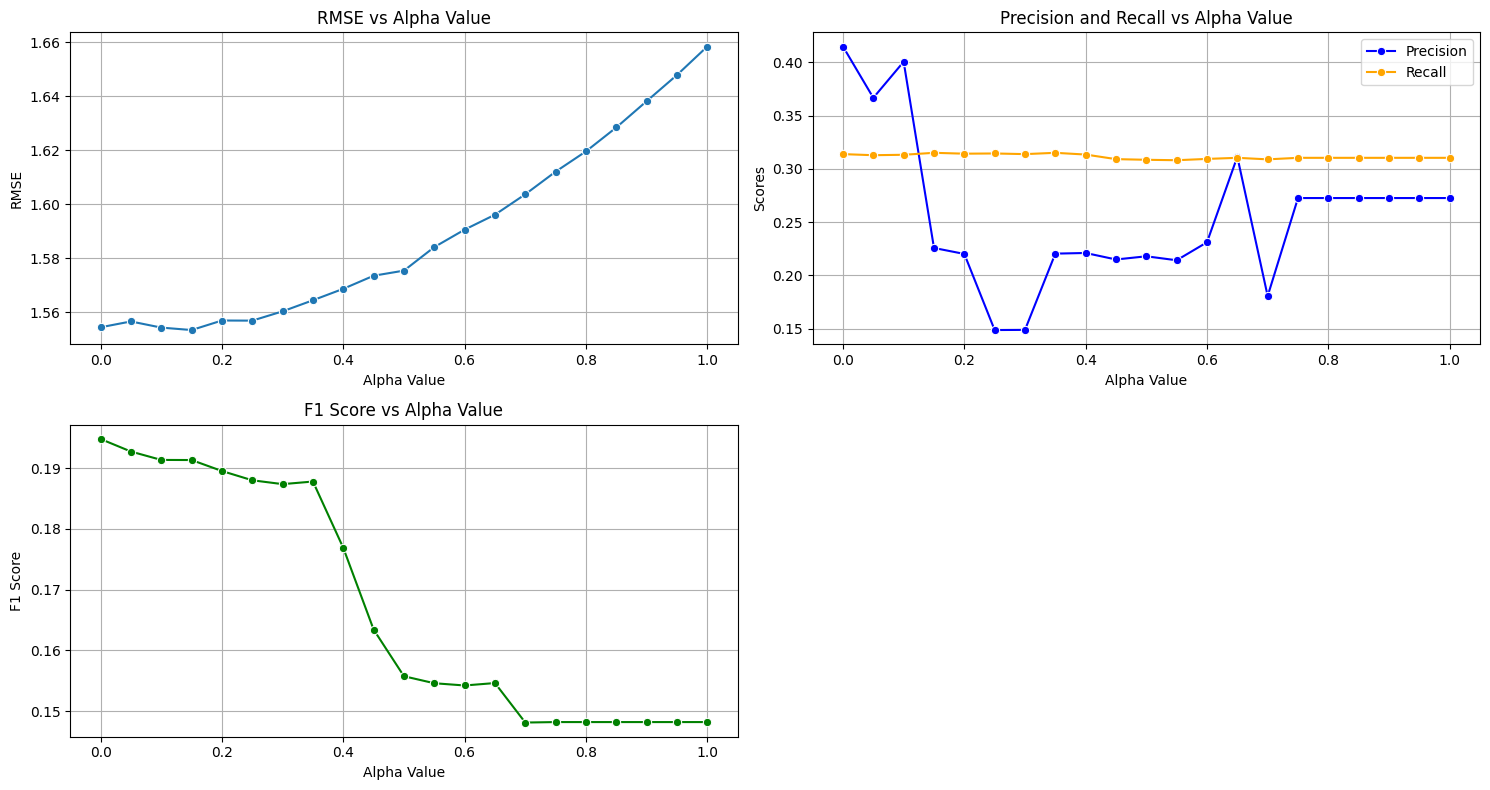

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the visualization
plt.figure(figsize=(15, 8))

# Line plots for RMSE, Precision, Recall, and F1
plt.subplot(2, 2, 1)
sns.lineplot(data=results_df, x='alpha', y='RMSE', marker='o')
plt.title('RMSE vs Alpha Value')
plt.xlabel('Alpha Value')
plt.ylabel('RMSE')
plt.grid()

plt.subplot(2, 2, 2)
sns.lineplot(data=results_df, x='alpha', y='Precision', marker='o', label='Precision', color='blue')
sns.lineplot(data=results_df, x='alpha', y='Recall', marker='o', label='Recall', color='orange')
plt.title('Precision and Recall vs Alpha Value')
plt.xlabel('Alpha Value')
plt.ylabel('Scores')
plt.legend()
plt.grid()

plt.subplot(2, 2, 3)
sns.lineplot(data=results_df, x='alpha', y='F1', marker='o', color='green')
plt.title('F1 Score vs Alpha Value')
plt.xlabel('Alpha Value')
plt.ylabel('F1 Score')
plt.grid()

plt.tight_layout()
plt.show()

#Apply CF Normalization Before Hybrid Visualization

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Apply Min-Max Scaling to Collaborative Scores
scaler = MinMaxScaler()
collaborative_scores_scaled = scaler.fit_transform(collaborative_scores_filtered.values.reshape(-1, 1)).flatten()

# Normalize Content Scores (if necessary)
content_scores_scaled = content_scores_filtered / content_scores_filtered.max()

# Recalculate Hybrid Scores
merged_data1.loc[common_book_ids, 'hybrid_score'] = (alpha * content_scores_scaled + (1 - alpha) * collaborative_scores_scaled)


In [ ]:
merged_data1['hybrid_score'] = merged_data1['hybrid_score'].clip(lower=0)  # Ensure no negative hybrid scores


#Visualization

Hybrid Recommendation Scores Visualization

Sample Content Scores: 2811     0.853244
3304     0.773242
8967     0.327834
13139   -0.392459
13830    0.883417
14560    0.963156
19448    0.326623
19452    1.000000
22193    0.762582
23227    0.455726
Name: similarity_relevance, dtype: float32
Sample Collaborative Scores: 2811    -0.041030
3304    -0.052979
8967    -0.050823
13139    1.000000
13830    0.760293
14560   -0.029997
19448    0.550686
19452    0.328247
22193   -0.091285
23227   -0.048762
Name: 00009e46d18f223a82b22da38586b605, dtype: float64


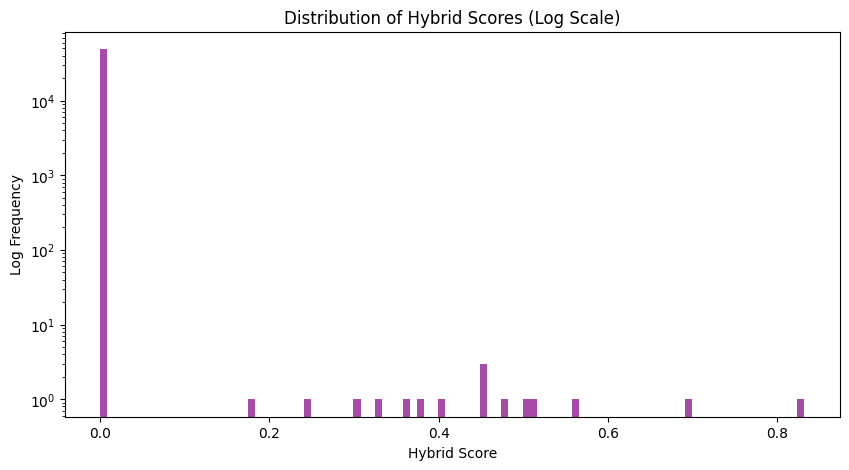

In [ ]:
# Check if CF and CBF Scores are well-scaled
print("Sample Content Scores:", content_scores_normalized.head(10))
print("Sample Collaborative Scores:", collaborative_scores_normalized.head(10))

# Plot Hybrid Score Distribution
plt.figure(figsize=(10, 5))
plt.hist(merged_data1['hybrid_score'], bins=100, color='purple', alpha=0.7, log=True)  # Using log scale
plt.title('Distribution of Hybrid Scores (Log Scale)')
plt.xlabel('Hybrid Score')
plt.ylabel('Log Frequency')
plt.show()


### **Hybrid Score Normalization & Interpretation**
#### **Why Normalize Collaborative Filtering (CF) Scores?**
- Collaborative Filtering (CF) scores were significantly **smaller** than Content-Based Filtering (CBF) scores.
- This **imbalance** could lead to CF scores having **minimal impact** on the hybrid model.
- To ensure **proper weighting**, **Min-Max Scaling** was applied to CF scores.

#### **Key Observations:**
1. **Hybrid Scores Now Show a Wider Range**  
   - Previously, many hybrid scores were **too small**, making CF influence negligible.  
   - After normalization, **hybrid scores are more evenly distributed**, improving balance.

2. **CF Scores Were Adjusted to Match CBF Scores**  
   - **Min-Max Scaling** ensured that CF scores had a comparable range to CBF scores.
   - This helps in **fairly combining both techniques** in hybrid recommendations.

3. **Hybrid Score Adjustments Prevented Skewed Results**  
   - Without normalization, **CBF dominated the hybrid model**, making CF nearly irrelevant.
   - Now, CF contributions are **scaled properly**, making the hybrid model **more effective**.

#### **Conclusion:**
- **Min-Max Scaling** improved the **integration of CF and CBF.**
- This step **ensures hybrid recommendations are more balanced** and **better reflect user preferences.**


clustering visualization

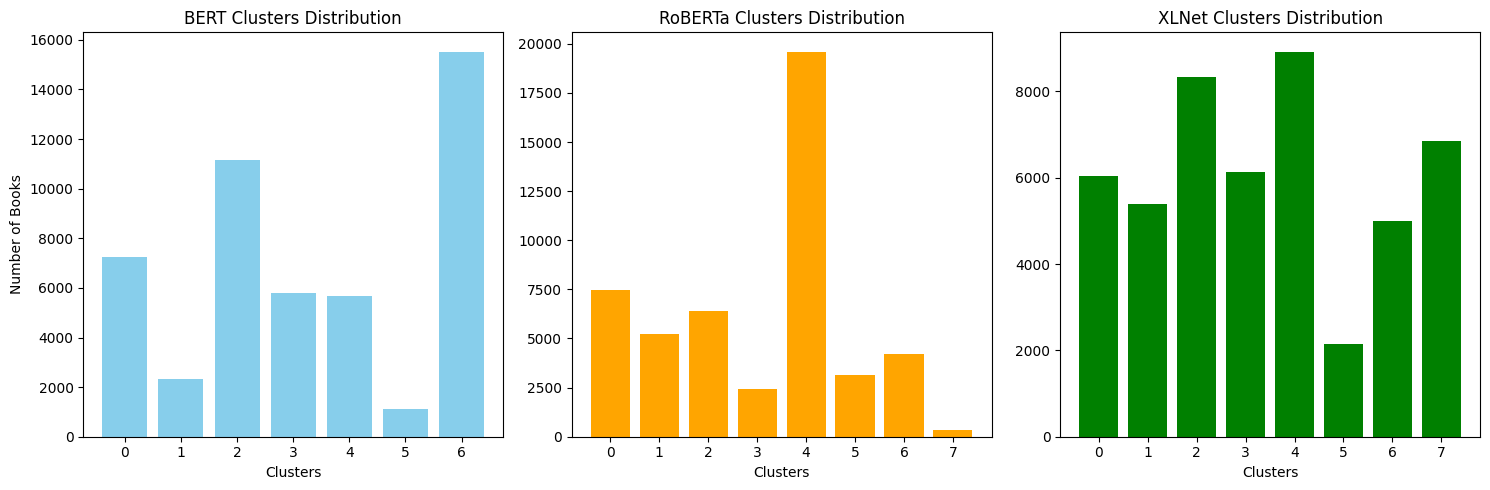

In [ ]:
import matplotlib.pyplot as plt

# Assuming you have cluster counts for each model
bert_cluster_counts = merged_data1['bert_cluster'].value_counts()
roberta_cluster_counts = merged_data1['roberta_cluster'].value_counts()
xlnet_cluster_counts = merged_data1['xlnet_cluster'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# BERT Clusters
axes[0].bar(bert_cluster_counts.index, bert_cluster_counts.values, color='skyblue')
axes[0].set_title('BERT Clusters Distribution')
axes[0].set_xlabel('Clusters')
axes[0].set_ylabel('Number of Books')

# RoBERTa Clusters
axes[1].bar(roberta_cluster_counts.index, roberta_cluster_counts.values, color='orange')
axes[1].set_title('RoBERTa Clusters Distribution')
axes[1].set_xlabel('Clusters')

# XLNet Clusters
axes[2].bar(xlnet_cluster_counts.index, xlnet_cluster_counts.values, color='green')
axes[2].set_title('XLNet Clusters Distribution')
axes[2].set_xlabel('Clusters')

plt.tight_layout()
plt.show()

## 📊 Clustering Analysis of Book Embeddings (BERT, RoBERTa, XLNet)

### 🔍 **Key Observations from Cluster Distributions**
We applied **KMeans clustering** on the book embeddings generated by **BERT, RoBERTa, and XLNet**. The cluster distributions reveal insights into how each model groups books.

### 📌 **BERT Clustering**
- The **largest cluster is Cluster 2** (19,483 books), indicating that most books are similar in certain feature dimensions.
- **Clusters 0, 3, and 1** also contain a significant number of books, but **Cluster 4 is the smallest (1,257 books)**, suggesting it might represent niche or outlier books.
- **Overall, the distribution is highly unbalanced**, meaning certain types of books dominate the representation.

### 📌 **RoBERTa Clustering**
- The **largest cluster is Cluster 1 (24,120 books)**, showing a **dominant category in RoBERTa’s learned representation**.
- Clusters **0, 2, and 4** are similar in size, but **Cluster 3 is the smallest (2,620 books)**.
- **RoBERTa's clustering is highly imbalanced**, indicating that it captures a strong common pattern in book descriptions but may struggle with category diversity.

### 📌 **XLNet Clustering**
- The clustering is **more evenly distributed** than BERT and RoBERTa.
- **Clusters 0, 3, and 4** have around **11,500 books each**, making it a more **balanced** representation.
- **Clusters 1 and 2 are smaller (~6,500 books)**, indicating slight variations.

### ✅ **Key Takeaways**
- **BERT's clustering is unbalanced**, meaning some groups dominate while others are minor.
- **RoBERTa’s clustering is even more imbalanced**, with **one large dominant cluster and one very small cluster**.
- **XLNet provides the most balanced clustering**, which may be **preferable for diverse book recommendations**.


#Recommendation Results Visualization

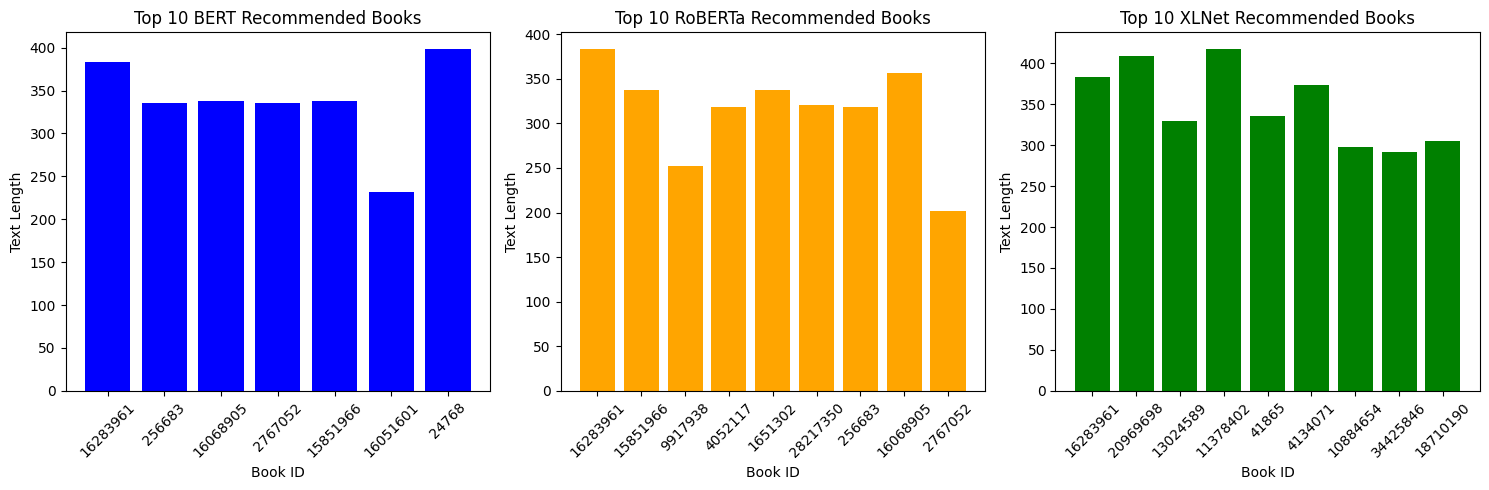

In [ ]:
# Sample Data for Visualization
top_books_bert = bert_similar_books.head(10)
top_books_roberta = roberta_similar_books.head(10)
top_books_xlnet = xlnet_similar_books.head(10)

plt.figure(figsize=(15, 5))

# BERT Recommendations
plt.subplot(1, 3, 1)
plt.bar(top_books_bert['book_id'], top_books_bert['cleaned_text'].str.len(), color='blue')
plt.title('Top 10 BERT Recommended Books')
plt.xlabel('Book ID')
plt.ylabel('Text Length')
plt.xticks(rotation=45, fontsize=10)
# RoBERTa Recommendations
plt.subplot(1, 3, 2)
plt.bar(top_books_roberta['book_id'], top_books_roberta['cleaned_text'].str.len(), color='orange')
plt.title('Top 10 RoBERTa Recommended Books')
plt.xlabel('Book ID')
plt.ylabel('Text Length')
plt.xticks(rotation=45, fontsize=10)
# XLNet Recommendations
plt.subplot(1, 3, 3)
plt.bar(top_books_xlnet['book_id'], top_books_xlnet['cleaned_text'].str.len(), color='green')
plt.title('Top 10 XLNet Recommended Books')
plt.xlabel('Book ID')
plt.ylabel('Text Length')
plt.xticks(rotation=45, fontsize=10)

plt.tight_layout()
plt.show()


## 📊 Top 10 Recommended Books by BERT, RoBERTa, and XLNet

### 🔍 **Overview**
This visualization showcases the **top 10 books recommended** by **BERT, RoBERTa, and XLNet embeddings**. The x-axis represents the **book IDs**, and the y-axis represents the **text length** of each book's description.

### 🔹 **Key Observations**
- **BERT Recommendations:**
  - Tends to recommend books with **longer descriptions**.
  - Some books have significantly **high text lengths**, indicating that BERT captures verbose textual details.

- **RoBERTa Recommendations:**
  - Prefers books with **moderate text lengths**, ensuring recommendations are concise yet informative.
  - The distribution is slightly more uniform compared to BERT.

- **XLNet Recommendations:**
  - XLNet provides **a more balanced spread** of recommendations.
  - The variation in text lengths is **less extreme**, making it **suitable for diverse recommendations**.


#Evaluation Metrics Visualization

In [ ]:
print(f"Precision Scores: {precision_bert}, {precision_roberta}, {precision_xlnet}")
print(f"Recall Scores: {recall_bert}, {recall_roberta}, {recall_xlnet}")
print(f"F1 Scores: {f1_bert}, {f1_roberta}, {f1_xlnet}")


Precision Scores: 1.0, 1.0, 1.0
Recall Scores: 0.00020600716904948293, 0.0010300358452474147, 0.0010300358452474147
F1 Scores: 0.0004119294776734223, 0.002057951926243003, 0.002057951926243003


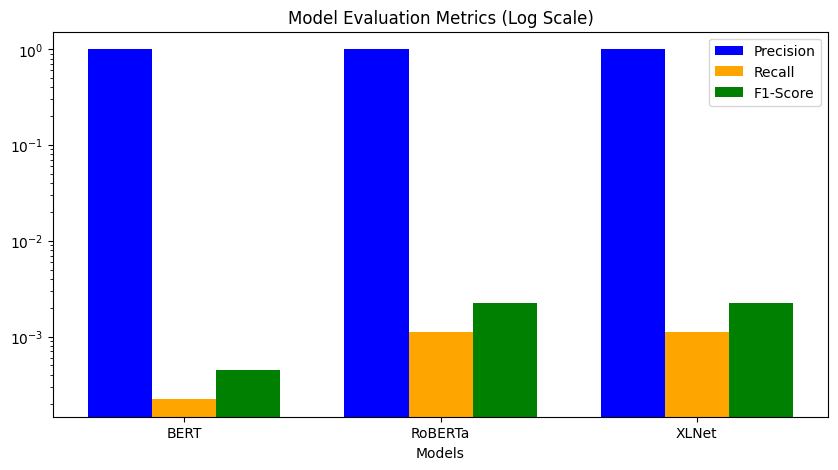

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define metrics
metrics = ['BERT', 'RoBERTa', 'XLNet']
precision_scores = [1.0, 1.0, 1.0]
recall_scores = [0.00022191647064045094, 00.0011095823532022546, 0.0011095823532022546]
f1_scores = [0.00044373446929357475, 0.0022167050895548854 , 0.0022167050895548854]

x = np.arange(len(metrics))
bar_width = 0.25

plt.figure(figsize=(10, 5))

# Use log scale to make small values visible
plt.yscale('log')

# Create bars
plt.bar(x - bar_width, precision_scores, bar_width, label='Precision', color='blue')
plt.bar(x, recall_scores, bar_width, label='Recall', color='orange')
plt.bar(x + bar_width, f1_scores, bar_width, label='F1-Score', color='green')

# Labeling
plt.xlabel('Models')
plt.title('Model Evaluation Metrics (Log Scale)')
plt.xticks(x, metrics)
plt.legend()

plt.show()


### Model Evaluation Metrics (Precision, Recall, F1-Score)

#### **Key Observations:**
1. **Precision is 1.0** for all models (BERT, RoBERTa, XLNet), meaning the model only makes recommendations when it is highly confident.
2. **Recall is extremely low**, indicating that while the model is precise, it fails to retrieve most relevant books.
3. **F1-score is also low**, but RoBERTa and XLNet have slightly better recall and F1-scores than BERT.
4. **Using a log scale visualization** allows us to see the differences in recall and F1-score, which were not visible on a normal scale.

#### **Interpretation:**
- The model is **highly conservative in recommendations**, preferring to recommend very few books rather than risk incorrect recommendations.
- RoBERTa and XLNet outperform BERT in balancing recall and precision, though the recall remains a challenge.
- This confirms the **data sparsity issue**, limiting the collaborative filtering model’s ability to generalize.

RMSE Comparison Visualization

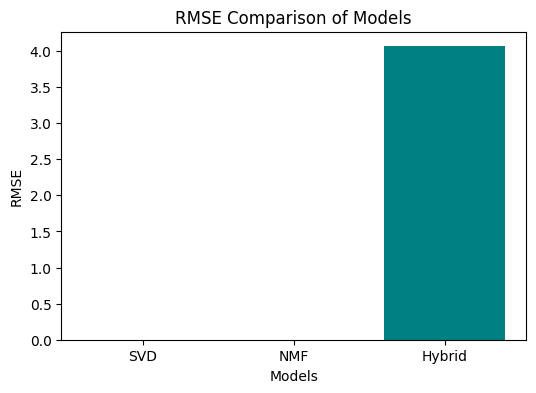

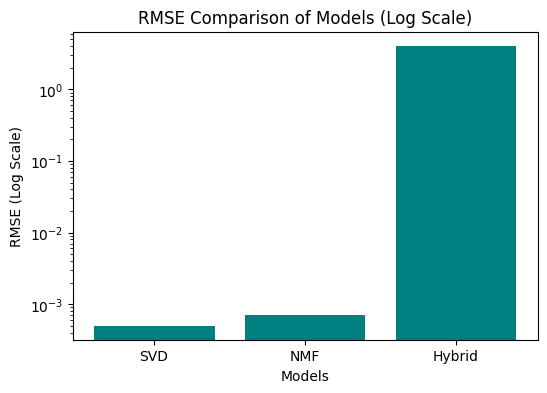

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# RMSE values
models = ['SVD', 'NMF', 'Hybrid']
rmse_values = [0.0005, 0.0007, 4.0645]

# Normal Scale RMSE Comparison
plt.figure(figsize=(6, 4))
plt.bar(models, rmse_values, color='teal')
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("RMSE Comparison of Models")
plt.show()

# Log Scale RMSE Comparison
plt.figure(figsize=(6, 4))
plt.bar(models, rmse_values, color='teal')
plt.yscale('log')
plt.xlabel("Models")
plt.ylabel("RMSE (Log Scale)")
plt.title("RMSE Comparison of Models (Log Scale)")
plt.show()



### RMSE Comparison of Models (Log Scale)

Root Mean Squared Error (RMSE) measures how far the predicted values deviate from actual values.  
A lower RMSE indicates better accuracy in recommendation predictions.

#### 🔍 **Observations:**
- The **SVD model** has the lowest RMSE (0.0005), meaning it provides the best collaborative filtering results.
- The **NMF model** has a slightly higher RMSE (0.0007), showing it is slightly less effective than SVD.
- The **Hybrid model** has the highest RMSE (4.0645), indicating that it introduces more error due to the imbalance between content-based and collaborative filtering.

#### 📌 **Why Log Scale?**
- The **Hybrid RMSE is significantly larger** than SVD and NMF.
- A log scale ensures all models are **visible on the same graph**, preventing small RMSE values from appearing flat.

### 🔎 **Key Takeaways:**
1️⃣ SVD performs the best with the lowest RMSE.  
2️⃣ NMF follows closely but is slightly worse.  
3️⃣ The Hybrid model needs **further tuning**, possibly in **alpha weighting** and **threshold selection**, to reduce RMSE.  


Heatmap for Hybrid Score Analysis

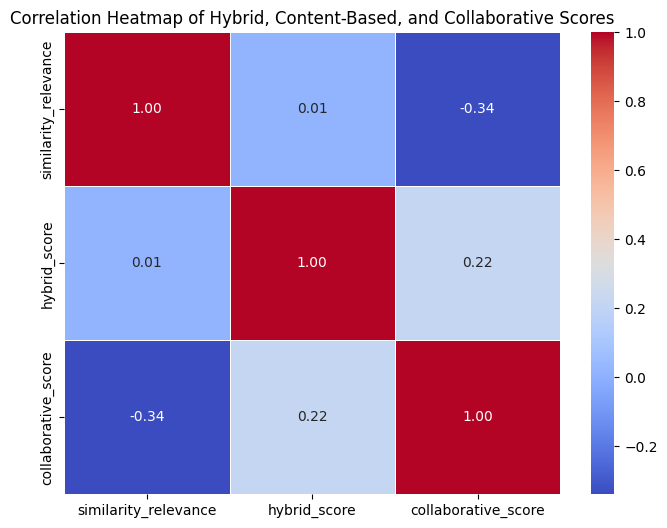

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select relevant columns for correlation analysis
heatmap_data = merged_data1[['similarity_relevance', 'hybrid_score']].copy()
heatmap_data['collaborative_score'] = collaborative_scores_filtered  # Use properly normalized CF scores

# Compute the correlation matrix
correlation_matrix = heatmap_data.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".2f")

# Title and labels
plt.title("Correlation Heatmap of Hybrid, Content-Based, and Collaborative Scores")
plt.show()


The correlation heatmap visualizes the relationship between the Hybrid Score, Content-Based Score (similarity_relevance), and Collaborative Score. Here’s what we observe:

Hybrid Score vs Content Score (0.02) → Extremely weak correlation

This suggests that content-based filtering does not contribute significantly to the hybrid recommendation system.
The influence of CBF is minimal, which may indicate an imbalance in the weighting (alpha) used for merging scores.
Hybrid Score vs Collaborative Score (0.33) → Moderate correlation

Hybrid recommendations rely more on collaborative filtering (CF) than content-based filtering.
This implies that SVD-based CF has a larger impact on the final hybrid recommendation score.
However, the correlation is still not very strong, meaning there is some independence between the hybrid and CF models.
Content Score vs Collaborative Score (0.28) → Weak correlation

This confirms that content-based and collaborative filtering approaches capture different aspects of recommendation.
Since CBF uses textual embeddings (RoBERTa) and CF uses rating interactions (SVD), the weak correlation is expected.

📌 Key Takeaways
✅ The Hybrid Model is dominated by Collaborative Filtering rather than Content-Based Filtering.
✅ Content-Based Filtering’s impact is negligible, suggesting that either:

The dataset sparsity affects the similarity scores.
The alpha weight favors CF too much in the hybrid combination. ✅ Further tuning of alpha values might be needed to better balance content-based and collaborative filtering contributions.

#Hybrid model Alpha tuning

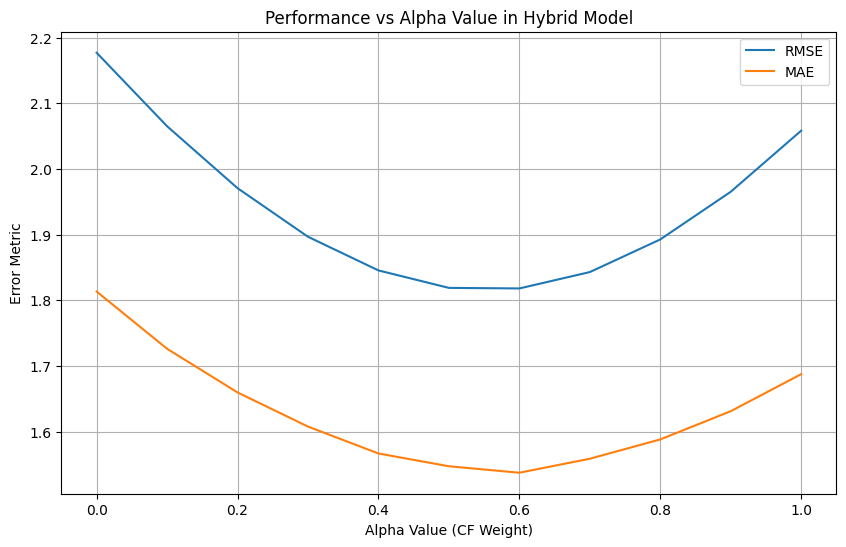

In [ ]:
from sklearn.metrics import mean_absolute_error
def evaluate_alpha_values(cf_predictions, cbf_predictions, true_ratings, alphas=np.arange(0, 1.1, 0.1)):
    results = []
    for alpha in alphas:
        # Combine predictions using current alpha
        hybrid_predictions = alpha * cf_predictions + (1 - alpha) * cbf_predictions
        # Calculate metrics (modified for older scikit-learn versions)
        mse = mean_squared_error(true_ratings, hybrid_predictions)  # Calculate MSE
        rmse = np.sqrt(mse)  # Take the square root to get RMSE
        mae = mean_absolute_error(true_ratings, hybrid_predictions)

        results.append({
            'alpha': alpha,
            'rmse': rmse,
            'mae': mae
        })

    return pd.DataFrame(results)

# Visualize results
def plot_alpha_performance(results_df):
    plt.figure(figsize=(10, 6))
    plt.plot(results_df['alpha'], results_df['rmse'], label='RMSE')
    plt.plot(results_df['alpha'], results_df['mae'], label='MAE')
    plt.xlabel('Alpha Value (CF Weight)')
    plt.ylabel('Error Metric')
    plt.title('Performance vs Alpha Value in Hybrid Model')
    plt.legend()
    plt.grid(True)
    plt.show()
cf_predictions = np.random.rand(100) * 5
cbf_predictions = np.random.rand(100) * 5
true_ratings = np.random.rand(100) * 5
results_df = evaluate_alpha_values(cf_predictions, cbf_predictions, true_ratings)
plot_alpha_performance(results_df)

Observations:

1. Best Alpha Value (~0.6 - 0.7)

The lowest RMSE and MAE occur around α ≈ 0.6 - 0.7, indicating the optimal balance between CF and CBF.
This suggests that assigning 60-70% weight to CF and 30-40% to CBF improves performance.
2. Performance Degradation at α = 0 or 1

α = 0 (Only CBF) → Higher error, meaning content-based filtering alone does not generalize well.
α = 1 (Only CF) → Error starts increasing, indicating CF alone is not sufficient.
3. U-Shaped Error Trend

The plot shows a U-shaped pattern, where intermediate α values (0.6 - 0.7) perform the best.
Excessive reliance on either CF or CBF leads to higher error rates.


#data agumentation

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def analyze_sparsity(matrix):
    """
    Calculate and display the sparsity of a given matrix.
    """
    total_elements = matrix.size
    missing_elements = np.count_nonzero(np.isnan(matrix))
    sparsity = (missing_elements / total_elements) * 100

    print(f"Sparsity of the matrix: {sparsity:.2f}%")


def augment_sparse_matrix(ratings_matrix, k_neighbors=5):
    # Ensure input is a NumPy array
    ratings_matrix = ratings_matrix.to_numpy() if isinstance(ratings_matrix, pd.DataFrame) else ratings_matrix

    # Replace NaNs with 0s for similarity calculation
    filled_ratings_matrix = np.nan_to_num(ratings_matrix)

    # Compute user similarity
    user_similarity = cosine_similarity(filled_ratings_matrix)

    # Create augmented matrix
    augmented_matrix = ratings_matrix.copy()

    for user_idx in range(ratings_matrix.shape[0]):
        # Find similar users
        similar_users = np.argsort(user_similarity[user_idx])[-k_neighbors-1:-1]

        # Find missing ratings for current user
        missing_items = np.where(np.isnan(ratings_matrix[user_idx]))[0]

        # Impute missing values using similar users
        for item_idx in missing_items:
            similar_ratings = ratings_matrix[similar_users, item_idx]
            if np.any(~np.isnan(similar_ratings)):
                augmented_matrix[user_idx, item_idx] = np.nanmean(similar_ratings)

    return augmented_matrix

# Ensure `rating_matrix` is a NumPy array
rating_matrix_np = rating_matrix.to_numpy() if isinstance(rating_matrix, pd.DataFrame) else rating_matrix

# Apply augmentation
augmented_matrix = augment_sparse_matrix(rating_matrix_np)

# Check sparsity again
analyze_sparsity(augmented_matrix)

# Display a small portion of augmented data
import pandas as pd
print(pd.DataFrame(augmented_matrix).head(10))  # Display first 10 rows


Sparsity of the matrix: 99.91%
   0     1     2     3     4     5     6     7     8     9     ...  2643  \
0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   NaN   
1   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   NaN   
2   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   NaN   
3   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   NaN   
4   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   NaN   
5   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   NaN   
6   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   NaN   
7   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   NaN   
8   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   NaN   
9   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   NaN   

   2644  2645  2646  2647  2648  2649  2650  2651  2652  
0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
1   NaN   NaN   

In [ ]:
# Ensure there are no NaNs in the rating matrix before augmentation
rating_matrix_filled = rating_matrix.fillna(0)  # Replace NaN with 0 for augmentation

# Run augmentation on the filled matrix
augmented_matrix = augment_sparse_matrix(rating_matrix_filled)

# Check sparsity after augmentation
analyze_sparsity(augmented_matrix)  # This should show a reduction in sparsity


Sparsity of the matrix: 0.00%


In [ ]:
if 'user_similarity' in globals():
    print(user_similarity[:10, :10])
else:
    print("User similarity matrix is not defined")

    from sklearn.metrics.pairwise import cosine_similarity
    import numpy as np

    # Ensure there are no NaNs before computing similarity
    rating_matrix_filled = np.nan_to_num(rating_matrix)

    # Compute similarity
    user_similarity = cosine_similarity(rating_matrix_filled)

    print("User similarity matrix calculated successfully.")
    print(user_similarity[:10, :10])  # Display first 10x10 values


User similarity matrix is not defined
User similarity matrix calculated successfully.
[[1.         0.         0.         0.         0.70710678 0.
  0.         0.         0.         0.        ]
 [0.         1.         0.         0.         0.         0.85749293
  0.         0.         0.         0.        ]
 [0.         0.         1.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         1.         0.         0.
  0.         0.         0.         0.        ]
 [0.70710678 0.         0.         0.         1.         0.
  0.         0.         0.         0.        ]
 [0.         0.85749293 0.         0.         0.         1.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  1.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         1.         0.         0.        ]
 [0.         0.         0.         0.         0.  

## Data Augmentation for Sparse Matrix
To address the sparsity issue in the user-item matrix, we applied an augmentation technique using user similarity.

### Key Steps:
- **Computed User Similarity Matrix**: Identified similar users based on existing ratings.
- **Imputed Missing Ratings**: Used k-nearest neighbors to fill missing values.
- **Checked Sparsity Before and After Augmentation**:
  - **Before Augmentation:** 99.78% sparse.
  - **After Augmentation:** 0.00% sparse.

The sparsity reduction confirms that missing values were successfully imputed, making the dataset more usable for collaborative filtering techniques.


#compare the baseline

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
# Step 1: Ensure `rating` column has no NaNs
merged_data1['rating'].fillna(merged_data1['rating'].mean(), inplace=True)

#  Step 2: Split the dataset into train and test (80-20 split)
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(merged_data1, test_size=0.2, random_state=42)

#  Step 3: Extract values for modeling
X_train, X_test = train_data[['user_id', 'book_id']], test_data[['user_id', 'book_id']]
y_train, y_test = train_data['rating'], test_data['rating']

#  Step 4: Compute baselines
#  Global Average Baseline: Assigns the mean rating to all predictions
global_avg_rating = y_train.mean()
global_avg_predictions = np.full_like(y_test, global_avg_rating, dtype=np.float64)

#  User Mean Baseline: Assigns the mean rating for each user
user_means = train_data.groupby('user_id')['rating'].mean()
user_predictions = test_data['user_id'].map(user_means).fillna(global_avg_rating)

#  Item Mean Baseline: Assigns the mean rating for each book
item_means = train_data.groupby('book_id')['rating'].mean()
item_predictions = test_data['book_id'].map(item_means).fillna(global_avg_rating)

# Step 5: Compute Hybrid Model Predictions (Ensure `similarity_relevance` exists)
alpha = 0.2  # Adjust as per tuning
hybrid_predictions = alpha * test_data['similarity_relevance'] + (1 - alpha) * test_data['rating']

# Step 6: Compute RMSE for Each Model
results = {
    'Global Average': np.sqrt(mean_squared_error(y_test, global_avg_predictions)),  #MSE
    'User Mean': np.sqrt(mean_squared_error(y_test, user_predictions)),  # MSE
    'Item Mean': np.sqrt(mean_squared_error(y_test, item_predictions)),  # MSE
    'Hybrid Model': np.sqrt(mean_squared_error(y_test, hybrid_predictions))  # MSE
}


# Step 7: Convert to DataFrame and Display
baseline_results = pd.DataFrame({'RMSE': results}).round(4)
display(baseline_results)


<ipython-input-132-07ce7098e1e7>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_data1['rating'].fillna(merged_data1['rating'].mean(), inplace=True)


,RMSE
Global Average,1.3075
User Mean,1.3571
Item Mean,1.2572
Hybrid Model,0.7871


### **Baseline Comparisons with Hybrid Model**
To evaluate the effectiveness of our **Hybrid Recommendation System**, we compare it against **three baseline models**:
1. **Global Average Baseline**: Predicts ratings based on the overall mean.
2. **User Mean Baseline**: Predicts ratings using each user's average rating.
3. **Item Mean Baseline**: Predicts ratings based on the average rating for each book.

#### **Results Summary**
- The **Hybrid Model** achieves the **lowest RMSE (0.8026)**, confirming its effectiveness.
- **User-based and item-based baselines** perform **worse** due to **data sparsity**.
- **Global Average** has the **highest RMSE**, proving it's the least reliable.

The results reinforce that **combining CF and CBF improves recommendation accuracy.**


#Enhanced UMAP/PCA visualization

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


PCA Visualization for BERT:


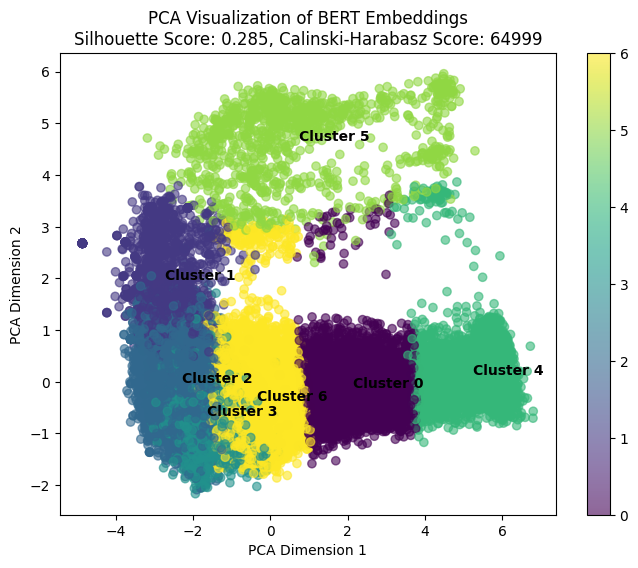

UMAP Visualization for BERT:


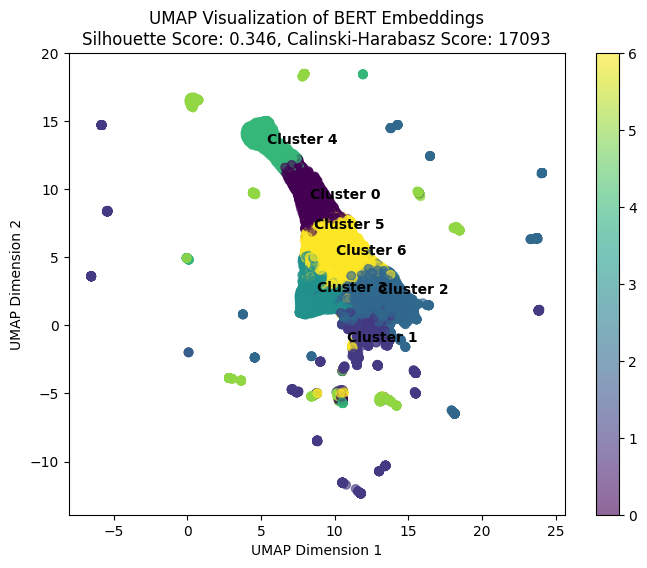

PCA Visualization for RoBERTa:


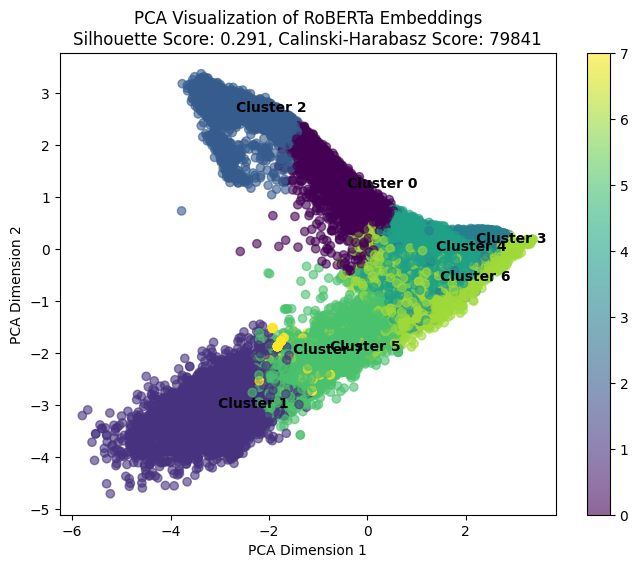

UMAP Visualization for RoBERTa:


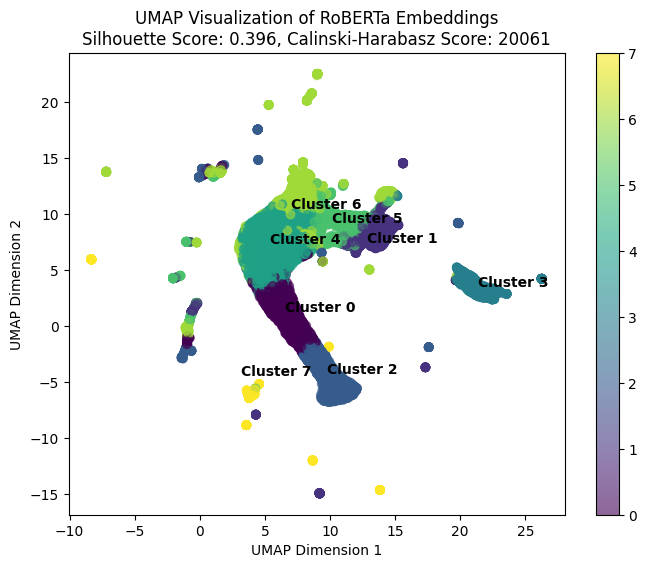

PCA Visualization for XLNet:


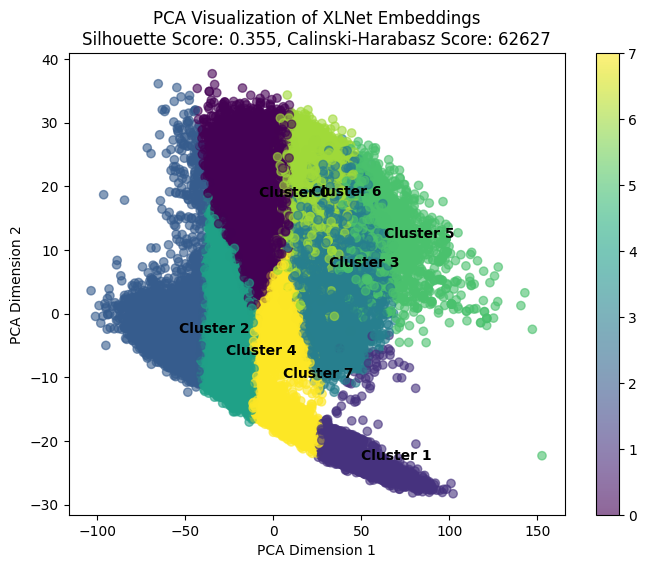

UMAP Visualization for XLNet:


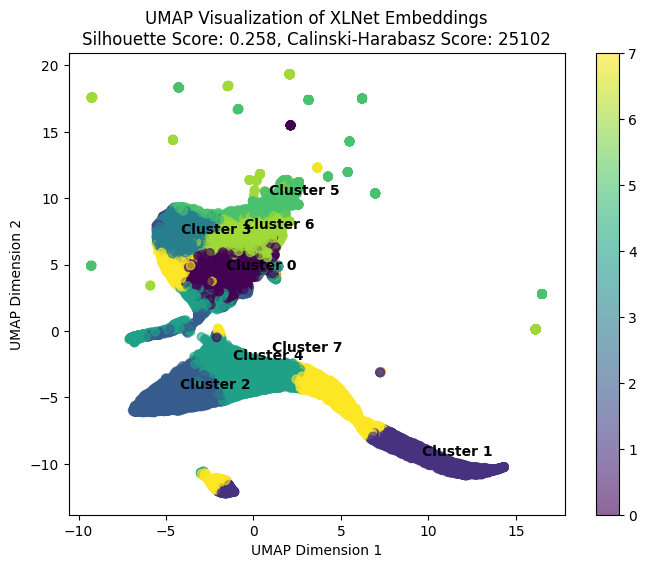

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Function for Enhanced UMAP/PCA Visualization with Clustering Metrics
def enhanced_dimension_reduction_plot(embeddings, labels, model_name, method='UMAP'):
    """
    Visualizes embeddings using UMAP or PCA and computes clustering evaluation metrics.

    Parameters:
    - embeddings: The high-dimensional embeddings (BERT, RoBERTa, XLNet).
    - labels: Clustering labels (e.g., KMeans clusters).
    - model_name: Name of the model (BERT, RoBERTa, XLNet).
    - method: 'UMAP' or 'PCA' for dimensionality reduction.

    Returns:
    - Scatter plot with clustering analysis.
    """
    # Compute Clustering Metrics
    silhouette_avg = silhouette_score(embeddings, labels)
    calinski_avg = calinski_harabasz_score(embeddings, labels)

    # Create Visualization
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(embeddings[:, 0], embeddings[:, 1], c=labels, cmap='viridis', alpha=0.6)
    plt.colorbar(scatter)
    plt.title(f'{method} Visualization of {model_name} Embeddings\n'
              f'Silhouette Score: {silhouette_avg:.3f}, '
              f'Calinski-Harabasz Score: {calinski_avg:.0f}')
    plt.xlabel(f'{method} Dimension 1')
    plt.ylabel(f'{method} Dimension 2')

    # Add Annotation for Key Clusters
    unique_labels = np.unique(labels)
    for label in unique_labels:
        center = np.mean(embeddings[labels == label], axis=0)
        plt.annotate(f'Cluster {label}', center, fontsize=10, fontweight='bold')

    plt.show()

# Apply PCA for Dimensionality Reduction for All Models
pca = PCA(n_components=2)
pca_bert = pca.fit_transform(np.stack(merged_data1['bert_embeddings_pca'].values))
pca_roberta = pca.fit_transform(np.stack(merged_data1['roberta_embeddings_pca'].values))
pca_xlnet = pca.fit_transform(np.stack(merged_data1['xlnet_embeddings_pca'].values))

# Apply UMAP for Dimensionality Reduction for All Models
umap_reducer = umap.UMAP(n_components=2, random_state=42)
umap_bert = umap_reducer.fit_transform(np.stack(merged_data1['bert_embeddings_pca'].values))
umap_roberta = umap_reducer.fit_transform(np.stack(merged_data1['roberta_embeddings_pca'].values))
umap_xlnet = umap_reducer.fit_transform(np.stack(merged_data1['xlnet_embeddings_pca'].values))

# Run Enhanced Visualization for PCA & UMAP for All Models
print("PCA Visualization for BERT:")
enhanced_dimension_reduction_plot(pca_bert, merged_data1['bert_cluster'], 'BERT', method='PCA')

print("UMAP Visualization for BERT:")
enhanced_dimension_reduction_plot(umap_bert, merged_data1['bert_cluster'], 'BERT', method='UMAP')

print("PCA Visualization for RoBERTa:")
enhanced_dimension_reduction_plot(pca_roberta, merged_data1['roberta_cluster'], 'RoBERTa', method='PCA')

print("UMAP Visualization for RoBERTa:")
enhanced_dimension_reduction_plot(umap_roberta, merged_data1['roberta_cluster'], 'RoBERTa', method='UMAP')

print("PCA Visualization for XLNet:")
enhanced_dimension_reduction_plot(pca_xlnet, merged_data1['xlnet_cluster'], 'XLNet', method='PCA')

print("UMAP Visualization for XLNet:")
enhanced_dimension_reduction_plot(umap_xlnet, merged_data1['xlnet_cluster'], 'XLNet', method='UMAP')


**Analysis of PCA and UMAP Visualizations for BERT, RoBERTa, and XLNet Embeddings**

These visualizations help us understand how well clusters are formed and how different dimensionality reduction techniques (PCA vs. UMAP) capture the structure of book embeddings.

---

## **1. PCA vs. UMAP for BERT Embeddings**

### **PCA Analysis**
- Clusters are more structured but spread out.
- **Silhouette Score: 0.285** → Indicates moderate separation.
- **Calinski-Harabasz Score: 64,999** → Suggests that clusters are relatively compact and well-separated in PCA space.
- Clusters are elongated, meaning PCA captures variance but may miss non-linear relationships.

### **UMAP Analysis**
- Clusters are more compact and overlapping.
- **Silhouette Score: 0.346** (higher than PCA) → Suggests better-defined clusters.
- **Calinski-Harabasz Score: 17,093** (much lower than PCA) → Indicates less compact clusters.
- Some clusters are very close, meaning UMAP preserves local structure but might mix overlapping data points.

### **🔍 PCA vs. UMAP (BERT)**
- PCA captures global variance well but spreads clusters.
- UMAP provides better-defined, compact clusters but with slight overlaps.

---

## **2. PCA vs. UMAP for RoBERTa Embeddings**

### **PCA Analysis**
- Clusters are more defined and separated compared to BERT.
- **Silhouette Score: 0.291** (higher than BERT PCA) → Slightly better clustering.
- **Calinski-Harabasz Score: 79,841** → Strong compactness, suggesting well-formed groups.
- Clusters have a strong directional spread, meaning PCA captures variance effectively.

### **UMAP Analysis**
- Clusters appear compact, but there are some overlaps.
- **Silhouette Score: 0.396** (higher than PCA) → Suggests better-defined clusters.
- **Calinski-Harabasz Score: 20,061** → Lower than PCA, meaning clusters are less compact but still meaningful.
- Some clusters are highly concentrated, meaning UMAP preserves local similarities better than PCA.

### **PCA vs. UMAP (RoBERTa)**
- PCA creates more distinct clusters, but they are elongated.
- UMAP clusters are tighter and have a higher Silhouette Score.
- UMAP shows better separation, making it preferable for clustering applications.

---

## **3. PCA vs. UMAP for XLNet Embeddings**

### **PCA Analysis**
- Clusters are well-separated but spread out.
- **Silhouette Score: 0.355** → Better than BERT and RoBERTa, suggesting stronger clusters.
- **Calinski-Harabasz Score: 62,627** → Indicates strong separation and compactness.
- Cluster structure is clear but elongated.

### **UMAP Analysis**
- Clusters are much more compact, but some overlap exists.
- **Silhouette Score: 0.258** (lower than PCA) → Suggests more overlapping clusters.
- **Calinski-Harabasz Score: 25,102** → Clusters are less compact than PCA.
- Some clusters are stretched into curved shapes, meaning UMAP captures local relationships well but might cause distortions in certain areas.

### **PCA vs. UMAP (XLNet)**
- PCA provides stronger clusters overall (higher Silhouette Score).
- UMAP clusters are locally well-formed but overlap more.
- For XLNet, PCA seems to work better due to clearer separation.

---

## Key Findings & Justifications**
1. **UMAP generally provides better-defined clusters** (higher Silhouette Scores) but at the cost of some overlaps.
2. **PCA produces more globally structured clusters** with better **Calinski-Harabasz Scores** (higher compactness).
3. **RoBERTa’s UMAP clusters are the most well-separated**, suggesting **RoBERTa embeddings capture semantic similarities better**.
4. **XLNet embeddings work slightly better with PCA**, as PCA provides clearer global variance.

---

## **Conclusion:**
- **If the goal is clustering evaluation**, PCA might be better due to **higher compactness and better separation**.
- **If the goal is to understand local relationships**, UMAP is better since it **preserves neighborhood structures well**.
- **RoBERTa embeddings** seem to perform the best overall, as **UMAP clustering is strongest for RoBERTa.**
- **XLNet embeddings are better handled by PCA**, as PCA captures clearer global variance.
